# 1BM130 – Group 5: Descriptive Analytics

All figures that appear in the Report are included in the order they appear.

Figures missing from the notebook are marked with a `TODO` placeholder.

Figures present in the notebook but not yet in the Report are marked with a 📌 note.

---

## Setup & Imports

In [1]:
import os
from pathlib import Path
from collections import defaultdict

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde


In [2]:
# Repository structure
ROOT_DIR = Path.cwd()
DATA_DIR = ROOT_DIR / 'Data'
EXTRA_DIR = DATA_DIR / 'Extra data'
CBS_DIR = DATA_DIR / 'CBS'
ODIN_DIR = DATA_DIR / 'OdiN' / 'ODiN2024 Updated with Header'

BUURT_TO_BUURT_PATH = EXTRA_DIR / 'buurt_to_buurt.csv'
BUURT_2025_PATH = EXTRA_DIR / 'buurt_2025.csv'
WIJK_2025_PATH = EXTRA_DIR / 'wijk_2025.csv'
PC6HNR2025_PATH = EXTRA_DIR / 'pc6hnr20250801_gwb.csv'
VOORZIENINGEN_PATH = EXTRA_DIR / 'voorzieningen_per_buurt_klasse.csv'
CBS_PATH = CBS_DIR / 'kwb2024.xlsx'
ODIN_PATH = ODIN_DIR / 'ODiN2024_DANS_Databestand_ Updated.xlsx'
GPKG_PATH = CBS_DIR / 'wijkenbuurten_2025_v1.gpkg'

IMAGES_DIR = ROOT_DIR / 'images'
CACHE_DIR = ROOT_DIR / 'cache'
for folder in (IMAGES_DIR, CACHE_DIR):
    folder.mkdir(exist_ok=True)

ACCESS_CACHE_PATH = CACHE_DIR / 'access_pipeline_v1.pkl'

print(f'Images folder: {IMAGES_DIR.resolve()}')
print(f'Cache folder: {CACHE_DIR.resolve()}')


Images folder: C:\Users\20192436\Projects\DesignforAI\images
Cache folder: C:\Users\20192436\Projects\DesignforAI\cache


## Data Loading

The following datasets are loaded:
- **buurt_to_buurt** - Network routing distances between neighbourhoods (SmartwayZ). The raw CSV is approximately 17 GB, so it is processed in chunks and cached instead of being kept fully in memory.
- **buurt_2025 / wijk** - CBS neighbourhood and district statistics
- **pc6hnr2025** - Postcode-to-neighbourhood crosswalk
- **voorzieningen** - Amenity locations per neighbourhood and category
- **cbs** - CBS kwb2024 socioeconomic indicators
- **odin_2024** - ODiN 2024 national travel survey


In [3]:
buurt_to_buurt_usecols = [
    'buurt_ori_id', 'buurt_id',
    'walk_2025_minutes', 'walk_2025_distance', 'walk_2025_detour_factor',
    'bike_2025_smart_minutes', 'bike_2025_smart_distance', 'bike_2025_smart_detour_factor',
    'ebike_2025_smart_minutes', 'ebike_2025_smart_distance', 'ebike_2025_smart_detour_factor',
]

buurt_to_buurt_dtypes = {
    'buurt_ori_id': 'string',
    'buurt_id': 'string',
    'walk_2025_minutes': 'float32',
    'walk_2025_distance': 'float32',
    'walk_2025_detour_factor': 'float32',
    'bike_2025_smart_minutes': 'float32',
    'bike_2025_smart_distance': 'float32',
    'bike_2025_smart_detour_factor': 'float32',
    'ebike_2025_smart_minutes': 'float32',
    'ebike_2025_smart_distance': 'float32',
    'ebike_2025_smart_detour_factor': 'float32',
}

buurt_to_buurt_preview = pd.read_csv(
    BUURT_TO_BUURT_PATH,
    usecols=buurt_to_buurt_usecols,
    dtype=buurt_to_buurt_dtypes,
    nrows=5,
)

buurt_to_buurt_preview


,buurt_ori_id,buurt_id,walk_2025_minutes,walk_2025_distance,walk_2025_detour_factor,bike_2025_smart_minutes,bike_2025_smart_distance,bike_2025_smart_detour_factor,ebike_2025_smart_minutes,ebike_2025_smart_distance,ebike_2025_smart_detour_factor
0,BU08553202,BU19480113,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,BU08553202,BU19480201,NaN,NaN,NaN,97.190002,28545.380859,1.15,78.370003,28643.359375,1.15
2,BU08553202,BU19480202,NaN,NaN,NaN,97.379997,28337.919922,1.16,78.349998,28402.029297,1.16
3,BU08553202,BU19480203,NaN,NaN,NaN,93.059998,27302.529297,1.15,74.660004,27379.699219,1.16
4,BU08553202,BU19480204,NaN,NaN,NaN,NaN,NaN,NaN,84.970001,31084.679688,1.13


In [4]:
file_size_gb = BUURT_TO_BUURT_PATH.stat().st_size / (1024 ** 3)
print(f'Routing file: {BUURT_TO_BUURT_PATH.name} ({file_size_gb:.2f} GB)')
print(f'Access cache: {ACCESS_CACHE_PATH.name}')


Routing file: buurt_to_buurt.csv (16.09 GB)
Access cache: access_pipeline_v1.pkl


In [5]:
buurt_2025 = pd.read_csv(BUURT_2025_PATH, sep=';')
buurt_2025.head()


,Buurt2025,buurtnaam2025
0,00140000,Binnenstad-Noord
1,00140001,Binnenstad-Zuid
2,00140002,Binnenstad-Oost
3,00140003,Binnenstad-West
4,00140004,Noorderplantsoen


In [6]:
wijk = pd.read_csv(WIJK_2025_PATH, sep=';')
wijk.head()


,Wijk2025,wijknaam2025
0,001400,Centrum
1,001401,Oud-Zuid
2,001402,Oud-West
3,001403,Oud-Noord
4,001404,Oud-Oost


In [7]:
pc6hnr2025 = pd.read_csv(
    PC6HNR2025_PATH,
    sep=';',
    usecols=['PC6', 'Buurt2025'],
    dtype={'PC6': 'string', 'Buurt2025': 'string'},
)
pc6hnr2025.head()


,PC6,Buurt2025
0,1011AB,0363AF01
1,1011AB,0363AF01
2,1011AB,0363AF01
3,1011AB,0363AF01
4,1011AB,0363AF01


In [8]:
voorzieningen = pd.read_csv(VOORZIENINGEN_PATH)
voorzieningen.head()


,buurtcode,klasse_apotheek,klasse_basisschool,klasse_bushalte,klasse_fastfood,klasse_horeca,klasse_huisarts,klasse_kinderopvang,klasse_kledingwinkel,klasse_restaurant,klasse_sportterrein,klasse_supermarkt,klasse_treinstation,klasse_voortgezet_onderwijs,klasse_ziekenhuis,aantal_drinkwaterpunt
0,BU00140000,0,2+,1,2+,2+,1,1,2+,2+,0,2+,0,0,0,7
1,BU00140001,2+,0,2+,2+,2+,2+,2+,2+,2+,0,2+,0,2+,2+,0
2,BU00140002,0,2+,2+,2+,2+,1,1,1,2+,0,0,0,2+,0,0
3,BU00140003,0,0,2+,2+,2+,0,1,2+,2+,0,1,0,0,0,0
4,BU00140004,0,0,1,0,1,0,1,0,1,0,0,0,0,0,2


In [9]:
cbs = pd.read_excel(CBS_PATH, decimal=',')
cbs.replace('.', np.nan, inplace=True)
cbs.head()


,gwb_code_10,gwb_code_8,regio,gm_naam,recs,gwb_code,ind_wbi,a_inw,a_man,a_vrouw,...,g_afs_kv,g_afs_sc,g_3km_sc,a_opp_ha,a_lan_ha,a_wat_ha,pst_mvp,pst_dekp,ste_mvs,ste_oad
0,NL00,0000,Nederland,Nederland,Land,NL00,NaN,17942942,8920768,9022174,...,0.7,0.8,9.8,4154337,3364723,789614,NaN,NaN,2,2070
1,GM0014,0014,Groningen,Groningen,Gemeente,GM0014,1,243768,120912,122856,...,0.6,0.8,9.4,19796,18553,1244,NaN,NaN,1,3472
2,WK001400,001400,Centrum,Groningen,Wijk,WK001400,1,24920,12845,12070,...,0.5,0.7,15.2,241,228,13,NaN,NaN,1,6766
3,BU00140000,00140000,Binnenstad-Noord,Groningen,Buurt,BU00140000,1,4745,2470,2270,...,0.6,0.5,16.1,39,37,2,9712,1,1,7001
4,BU00140001,00140001,Binnenstad-Zuid,Groningen,Buurt,BU00140001,1,6975,3640,3340,...,0.6,0.8,14.4,59,55,4,9711,1,1,6698


In [10]:
odin_columns = [
    'AfstV', 'KHvm', 'Hvm', 'Reisduur', 'Doel', 'FactorV', 'Verpl',
    'Sted', 'Prov', 'HHGestInkG', 'KLeeft', 'MaatsPart_DANS24',
    'Opleiding_DANS24', 'VertPC_PRAM'
]

odin_2024 = pd.read_excel(ODIN_PATH, usecols=odin_columns, decimal=',')
odin_2024.replace('.', np.nan, inplace=True)
odin_2024.head()


,Sted,Prov,KLeeft,MaatsPart_DANS24,Opleiding_DANS24,HHGestInkG,Verpl,Doel,VertPC_PRAM,AfstV,Hvm,KHvm,Reisduur,FactorV
0,3,5,16,5,3,6,1.0,9.0,8211.0,1300.0,1.0,1.0,120.0,20705.362492
1,3,5,16,5,3,6,1.0,9.0,6721.0,700.0,1.0,1.0,60.0,20705.362492
2,3,5,16,5,3,6,1.0,1.0,6846.0,1200.0,1.0,1.0,105.0,20705.362492
3,5,6,8,2,3,10,1.0,2.0,6669.0,380.0,1.0,1.0,35.0,89049.971908
4,5,6,8,2,3,10,1.0,1.0,3772.0,380.0,1.0,1.0,35.0,89049.971908


## Data Preprocessing

Variables are constructed from the ODiN and CBS codebooks. See Tables 1.1–1.7 in the Report for a full description of all variables used.

In [11]:
df = odin_2024.copy()
# AfstV is in hm, convert to km using /10
df['dist_km']      = df['AfstV'] / 10
# KHvm is bike usage
df['is_bike']      = df['KHvm'] == 5
df['is_car']       = df['Hvm'] == 1
df['is_walk']      = df['Hvm'] == 9
# add within 3 km bool
df['within3km']    = df['dist_km'] <= 3.0
# Same for within 10 minutes
df['within10min'] = df['Reisduur'] <= 10
# Essentials are (according to smartwayz): education, grocery shopping, services
df['is_essential'] = df['Doel'].isin([7, 8, 13])
# trip level weight we should always use this factor to get representative trip shares
df['wV'] = pd.to_numeric(df['FactorV'], errors='coerce').fillna(0)

#Keeping only regular trips
df = df[df['Verpl'] == 1].copy()

# Mode labels (from Hvm) for plots
mode_map = {1:'Car', 2:'Train', 3:'Bus', 4:'Tram', 5:'Metro',
            6:'Speedpedelec', 7:'E-bike', 8:'Bicycle', 9:'Walking',
            11:'Van', 16:'Motorcycle', 17:'Moped', 18:'Scooter', 14:'Taxi'}
df['mode_label'] = df['Hvm'].map(mode_map)

# Simplified modes to 6 groups for cleaner charts
simplify = {'Speedpedelec':'Cycling (all)', 'E-bike':'Cycling (all)', 'Bicycle':'Cycling (all)',
            'Tram':'Public transport', 'Metro':'Public transport', 'Bus':'Public transport',
            'Van':'Other', 'Motorcycle':'Other', 'Moped':'Other', 'Scooter':'Other', 'Taxi':'Other'}
df['mode_simple'] = df['mode_label'].replace(simplify)

# added provinces labels and city or not
sted_map = {1:'Very strongly urban', 2:'Strongly urban', 3:'Moderately urban',
            4:'Slightly urban', 5:'Not urban'}
prov_map = {1:'Groningen', 2:'Fryslân', 3:'Drenthe', 4:'Overijssel', 5:'Flevoland',
            6:'Gelderland', 7:'Utrecht', 8:'Noord-Holland', 9:'Zuid-Holland',
            10:'Zeeland', 11:'Noord-Brabant', 12:'Limburg'}
df['sted_label'] = df['Sted'].map(sted_map)
df['prov_label']  = df['Prov'].map(prov_map)

# HHGestInkG is standardised household income decile (1=lowest, 10 = highest)
df['income_group'] = pd.cut(df['HHGestInkG'],
    bins=[0, 2, 4, 6, 8, 10],
    labels=['Low\n(1–2)', 'Low-mid\n(3–4)', 'Middle\n(5–6)',
            'High-mid\n(7–8)', 'High\n(9–10)'])

# Bike type labels (from Hvm for bikes: 6=Speed pedelec, 7=E-bike, 8=Bicycle)
bike_labels = {6: 'Speed pedelec', 7: 'E-bike', 8: 'Bicycle'}
df['bike_type'] = df['Hvm'].map(bike_labels)

# Age group labels
age_labels = {
    2: '6-11', 3: '12-14', 4: '15-17', 5: '18-19',
    6: '20-24', 7: '25-29', 8: '30-34', 9: '35-39',
    10: '40-44', 11: '45-49', 12: '50-54', 13: '55-59',
    14: '60-64', 15: '65-69', 16: '70-74', 17: '75-79',
    18: '80+'
}
df['age_group'] = df['KLeeft'].map(age_labels)

# plot theme, can change
sns.set_theme(style='whitegrid', font='sans-serif', font_scale=1.1)
COLORS = sns.color_palette('tab10')

### Neighbourhood-level merge (ODiN → CBS → SmartwayZ)

Neighbourhood codes are normalised and the three datasets are joined into a single analysis dataframe.

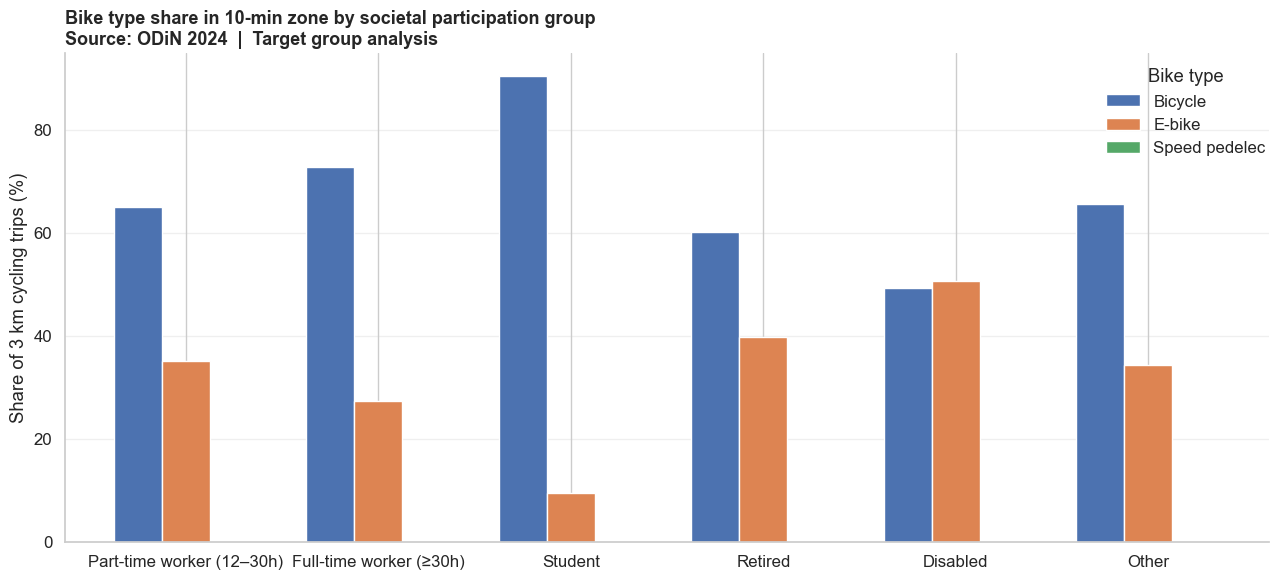

In [23]:
df_trips = odin_2024.copy()
df_trips['dist_km']      = df_trips['AfstV'] / 10
# KHvm is bike usage
df_trips['is_bike']      = df_trips['KHvm'] == 5
df_trips['is_car']       = df_trips['Hvm'] == 1
df_trips['is_walk']      = df_trips['Hvm'] == 9
# add within 3 km bool
df_trips['within3km']    = df_trips['dist_km'] <= 3.0

df_trips['dist_km']      = df_trips['AfstV'] / 10
# KHvm is bike usage
df_trips['is_bike']      = df_trips['KHvm'] == 5
df_trips['is_car']       = df_trips['Hvm'] == 1
df_trips['is_walk']      = df_trips['Hvm'] == 9
# add within 3 km bool
df_trips['within3km']    = df_trips['dist_km'] <= 3.0
# Same for within 10 minutes
df_trips['within10min'] = df_trips['Reisduur'] <= 10
# Essentials are (according to smartwayz): education, grocery shopping, services
df_trips['is_essential'] = df_trips['Doel'].isin([7, 8, 13])
# trip level weight we should always use this factor to get representative trip shares
df_trips['wV'] = pd.to_numeric(df_trips['FactorV'], errors='coerce').fillna(0)

#Keeping only regular trips
df_trips = df_trips[df_trips['Verpl'] == 1].copy()

# # Mode labels (from Hvm) for plots
# mode_map = {1:'Car', 2:'Train', 3:'Bus', 4:'Tram', 5:'Metro',
#             6:'Speedpedelec', 7:'E-bike', 8:'Bicycle', 9:'Walking',
#             11:'Van', 16:'Motorcycle', 17:'Moped', 18:'Scooter', 14:'Taxi'}
# df_trips['mode_label'] = df_trips['Hvm'].map(mode_map)

# # Simplified modes to 6 groups for cleaner charts
# simplify = {'Speedpedelec':'Cycling (all)', 'E-bike':'Cycling (all)', 'Bicycle':'Cycling (all)',
#             'Tram':'Public transport', 'Metro':'Public transport', 'Bus':'Public transport',
#             'Van':'Other', 'Motorcycle':'Other', 'Moped':'Other', 'Scooter':'Other', 'Taxi':'Other'}
# df_trips['mode_simple'] = df_trips['mode_label'].replace(simplify)

# # HHGestInkG is standardised household income decile (1=lowest, 10 = highest)
# df_trips['income_group'] = pd.cut(df_trips['HHGestInkG'],
#     bins=[0, 2, 4, 6, 8, 10],
#     labels=['Low\n(1–2)', 'Low-mid\n(3–4)', 'Middle\n(5–6)',
#             'High-mid\n(7–8)', 'High\n(9–10)'])

# Bike type labels (from Hvm for bikes: 6=Speed pedelec, 7=E-bike, 8=Bicycle)
bike_labels = {6: 'Speed pedelec', 7: 'E-bike', 8: 'Bicycle'}
df_trips['bike_type'] = df_trips['Hvm'].map(bike_labels)

# Mode labels (from Hvm) for plots
mode_map_trips = {1:'Car', 2:'Train', 3:'Bus', 4:'Tram', 5:'Metro',
                  6:'Speedpedelec', 7:'E-bike', 8:'Bicycle', 9:'Walking',
                  11:'Van', 16:'Motorcycle', 17:'Moped', 18:'Scooter', 14:'Taxi'}
df_trips['mode_label'] = df_trips['Hvm'].map(mode_map_trips)
simplify_trips = {'Speedpedelec':'Cycling (all)', 'E-bike':'Cycling (all)', 'Bicycle':'Cycling (all)',
                  'Tram':'Public transport', 'Metro':'Public transport', 'Bus':'Public transport',
                  'Van':'Other', 'Motorcycle':'Other', 'Moped':'Other', 'Scooter':'Other', 'Taxi':'Other'}
df_trips['mode_simple'] = df_trips['mode_label'].replace(simplify_trips)
# Province and urbanisation labels
df_trips['prov_label'] = df_trips['Prov'].map(prov_map)
df_trips['sted_label'] = df_trips['Sted'].map(sted_map)
# Age group labels
df_trips['age_group'] = df_trips['KLeeft'].map(age_labels)
# Income group (standardised household income decile)
df_trips['income_group'] = pd.cut(df_trips['HHGestInkG'],
    bins=[0, 2, 4, 6, 8, 10],
    labels=['Low\n(1–2)', 'Low-mid\n(3–4)', 'Middle\n(5–6)',
            'High-mid\n(7–8)', 'High\n(9–10)'])

maats_map = {
    1: 'Part-time worker (12–30h)',
    2: 'Full-time worker (≥30h)',
    3: 'Student',
    4: 'Retired',
    5: 'Disabled',
    6: 'Other'
}
maats_order = list(maats_map.values())
df_trips['maats_label'] = df_trips['MaatsPart_DANS24'].map(maats_map) 


bike_maats = df_trips[
    df_trips['within3km'] &
    df_trips['bike_type'].notna() &
    df_trips['maats_label'].notna()
]

# --- Weighted counts per group ---
grouped = (
    bike_maats
    .groupby(['maats_label', 'bike_type'], observed=True)['wV']
    .sum()
    .reset_index(name='count')
)

# --- Total weighted trips per participation group ---
totals = (
    bike_maats
    .groupby('maats_label', observed=True)['wV']
    .sum()
    .reset_index(name='total')
)

# --- Merge + compute share ---
grouped = grouped.merge(totals, on='maats_label')
grouped['share_pct'] = grouped['count'] / grouped['total'] * 100

# --- Ensure all bike types appear as columns ---
all_bike_types = sorted(df_trips['bike_type'].dropna().unique())

pivot = (
    grouped
    .pivot(index='maats_label', columns='bike_type', values='share_pct')
    .reindex(maats_order)          # correct order of rows
    .reindex(columns=all_bike_types)  # consistent bike type order
    .fillna(0)
)

# --- Plot ---
fig, ax = plt.subplots(figsize=(13, 6))
pivot.plot(kind='bar', ax=ax, width=0.75, edgecolor='white')

ax.set_ylabel('Share of 3 km cycling trips (%)')
ax.set_xlabel('')
ax.set_title(
    'Bike type share in 10-min zone by societal participation group\n'
    'Source: ODiN 2024  |  Target group analysis',
    fontsize=13, fontweight='bold', loc='left'
)

ax.set_xticklabels(maats_order, rotation=0, ha='center')
ax.legend(title='Bike type', bbox_to_anchor=(1.01, 1), frameon=False)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


In [24]:
# Normalise neighbourhood keys

def to_buurt8(code):
    if pd.isna(code):
        return np.nan
    value = str(code).strip()
    if value.lower().startswith('bu'):
        value = value[2:]
    return value.zfill(8)


def assign_quantile_groups(series, labels):
    numeric = pd.to_numeric(series, errors='coerce')
    out = pd.Series(pd.NA, index=series.index, dtype='object')
    valid = numeric.dropna()
    if valid.empty:
        return out.astype(pd.CategoricalDtype(categories=labels, ordered=True))

    quantiles = pd.qcut(valid, q=len(labels), labels=False, duplicates='drop')
    used_codes = sorted({int(code) for code in pd.Series(quantiles).dropna().tolist()})
    mapping = {code: labels[idx] for idx, code in enumerate(used_codes)}
    out.loc[quantiles.index] = quantiles.map(mapping)
    return out.astype(pd.CategoricalDtype(categories=labels, ordered=True))


cbs['buurt_key'] = cbs['gwb_code_8'].astype(str).str.zfill(8)
cbs_buurt = cbs[cbs['recs'] == 'Buurt'].copy()
voorzieningen['buurt_key'] = voorzieningen['buurtcode'].apply(to_buurt8)
pc6hnr2025['buurt_key'] = pc6hnr2025['Buurt2025'].apply(to_buurt8)

# Map neighbourhoods to their dominant PC4 for the ODiN merge
pc6hnr2025['PC4'] = pd.to_numeric(pc6hnr2025['PC6'].str[:4], errors='coerce')
buurt_pc4_counts = pc6hnr2025.groupby(['buurt_key', 'PC4'], observed=True).size().reset_index(name='address_count')
buurt_to_dominant_pc4 = (
    buurt_pc4_counts
    .sort_values('address_count', ascending=False)
    .drop_duplicates('buurt_key')[['buurt_key', 'PC4']]
)

# Compute weighted ODiN behaviour at PC4 level and project it to neighbourhoods
odin_2024['VertPC_PRAM'] = pd.to_numeric(odin_2024['VertPC_PRAM'], errors='coerce')
essential_cycling = odin_2024[
    (odin_2024['KHvm'] == 5) &
    (odin_2024['Doel'].isin([7, 8, 13]))
].copy()
essential_cycling['within_3km'] = (pd.to_numeric(essential_cycling['AfstV'], errors='coerce') / 10) <= 3
essential_cycling['FactorV'] = pd.to_numeric(essential_cycling['FactorV'], errors='coerce').fillna(0)
essential_cycling['AfstV'] = pd.to_numeric(essential_cycling['AfstV'], errors='coerce')


def weighted_usage(x):
    weight_sum = x['FactorV'].sum()
    if weight_sum == 0:
        return np.nan
    return np.average(x['within_3km'], weights=x['FactorV']) * 100


odin_pc4 = (
    essential_cycling
    .groupby('VertPC_PRAM', observed=True)
    .apply(lambda x: pd.Series({
        'pct_within_3km': weighted_usage(x),
        'mean_dist_km': np.average(x['AfstV'] / 10, weights=x['FactorV']) if x['FactorV'].sum() > 0 else np.nan,
        'n_trips_weighted': x['FactorV'].sum(),
    }))
    .reset_index()
    .rename(columns={'VertPC_PRAM': 'PC4'})
)
odin_buurt = buurt_to_dominant_pc4.merge(odin_pc4, on='PC4', how='left')

# Preserve amenity density counts
amenity_cols = [c for c in voorzieningen.columns if c not in ('buurtcode', 'buurt_key', 'aantal_drinkwaterpunt')]
for col in amenity_cols:
    voorzieningen[col] = voorzieningen[col].replace({'2+': 1})
    voorzieningen[col] = pd.to_numeric(voorzieningen[col], errors='coerce').fillna(0).astype(int)
voorzieningen_lookup = voorzieningen[['buurt_key'] + amenity_cols].copy()

# Use the most complete neighbourhood affluence metric that is available
income_order = ['Low', 'Low-mid', 'Middle', 'High-mid', 'High']
income_score_map = {'Low': 1, 'Low-mid': 2, 'Middle': 3, 'High-mid': 4, 'High': 5}
income_slug_map = {'Low': 'low', 'Low-mid': 'low_mid', 'Middle': 'middle', 'High-mid': 'high_mid', 'High': 'high'}
income_metric_candidates = ['g_ink_pi', 'g_wozbag']
income_metric_coverage = {
    col: pd.to_numeric(cbs_buurt[col], errors='coerce').notna().sum()
    for col in income_metric_candidates
    if col in cbs_buurt.columns
}
income_metric_col = max(income_metric_coverage, key=income_metric_coverage.get)

dest_profile = cbs_buurt[['buurt_key', 'gm_naam', 'a_inw', income_metric_col]].copy()
dest_profile['a_inw'] = pd.to_numeric(dest_profile['a_inw'], errors='coerce')
dest_profile[income_metric_col] = pd.to_numeric(dest_profile[income_metric_col], errors='coerce')
dest_profile = dest_profile[dest_profile['a_inw'].fillna(0) > 0].copy()
dest_profile['dest_income_group'] = assign_quantile_groups(dest_profile[income_metric_col], income_order)
dest_profile['dest_income_score'] = dest_profile['dest_income_group'].map(income_score_map)
dest_profile = dest_profile.dropna(subset=['dest_income_group']).copy()
dest_profile_lookup = dest_profile[['buurt_key', 'a_inw', 'dest_income_group', 'dest_income_score']].copy()

# Chunked processing + cache for the 17 GB routing table
routing_labels = ['bike10', 'ebike10', 'walk15', 'bike10_direct', 'ebike10_direct', 'walk15_direct']


def build_access_frame(accumulator, label):
    cols = ['buurt_key'] + [f'{label}_{c}' for c in amenity_cols]
    if not accumulator:
        return pd.DataFrame(columns=cols)

    records = []
    for buurt_key, values in accumulator.items():
        records.append([buurt_key] + values.tolist())
    acc_df = pd.DataFrame(records, columns=cols)

    fac_cols = [c for c in acc_df.columns if c.startswith(f'{label}_klasse')]
    acc_df[f'{label}_score'] = (acc_df[fac_cols] >= 1).sum(axis=1)
    acc_df[f'{label}_total_facilities'] = acc_df[fac_cols].sum(axis=1)
    return acc_df


amenity_weights = {
    'klasse_supermarkt': 0.18,
    'klasse_huisarts': 0.14,
    'klasse_basisschool': 0.13,
    'klasse_ziekenhuis': 0.10,
    'klasse_apotheek': 0.07,
    'klasse_voortgezet_onderwijs': 0.07,
    'klasse_bushalte': 0.06,
    'klasse_treinstation': 0.05,
    'klasse_kinderopvang': 0.03,
    'klasse_horeca': 0.05,
    'klasse_restaurant': 0.04,
    'klasse_sportterrein': 0.04,
    'klasse_fastfood': 0.02,
    'klasse_kledingwinkel': 0.02,
}


def compute_weighted_score(acc_df, label, weights):
    score = pd.Series(0.0, index=acc_df.index)
    active_columns = []
    for fac, weight in weights.items():
        col = f'{label}_{fac}'
        if col not in acc_df.columns:
            continue
        values = pd.to_numeric(acc_df[col], errors='coerce').fillna(0)
        if values.nunique(dropna=True) <= 1:
            continue
        active_columns.append((values, weight))

    total_weight = sum(weight for _, weight in active_columns)
    if total_weight == 0:
        acc_df[f'{label}_weighted_score'] = score
        return acc_df

    for values, weight in active_columns:
        score += values.rank(pct=True) * 100 * (weight / total_weight)

    acc_df[f'{label}_weighted_score'] = score
    return acc_df



def build_social_exposure_frame(accumulator, label):
    cols = ['buurt_key'] + [f'{label}_pop_{income_slug_map[group]}' for group in income_order]
    if not accumulator:
        return pd.DataFrame(columns=cols)

    pop_by_group = pd.DataFrame.from_dict(accumulator, orient='index', columns=income_order).fillna(0.0)
    pop_by_group.index.name = 'buurt_key'
    reachable_pop = pop_by_group.sum(axis=1)
    share_df = pop_by_group.div(reachable_pop.replace(0, np.nan), axis=0)
    safe_shares = share_df.where(share_df > 0)
    shannon = -(safe_shares * np.log(safe_shares)).sum(axis=1).fillna(0)
    shannon_norm = shannon / np.log(len(income_order))
    effective_groups = np.exp(shannon)
    mean_income_score = share_df.mul(pd.Series(income_score_map), axis=1).sum(axis=1)

    out = pd.DataFrame({
        'buurt_key': pop_by_group.index,
        f'{label}_reachable_pop': reachable_pop.values,
        f'{label}_n_income_groups': (pop_by_group > 0).sum(axis=1).values,
        f'{label}_shannon': shannon.values,
        f'{label}_shannon_norm': shannon_norm.values,
        f'{label}_effective_income_groups': effective_groups.values,
        f'{label}_mean_income_score': mean_income_score.values,
    })

    for group in income_order:
        slug = income_slug_map[group]
        out[f'{label}_pop_{slug}'] = pop_by_group[group].values
        out[f'{label}_share_{slug}'] = share_df[group].fillna(0).values

    return out


if ACCESS_CACHE_PATH.exists():
    cache_payload = pd.read_pickle(ACCESS_CACHE_PATH)
    access_all = cache_payload['access_all']
    origin_detour = cache_payload['origin_detour']
    walk_exposure = cache_payload['walk_exposure']
    bike_exposure = cache_payload['bike_exposure']
    cache_summary = cache_payload['cache_summary']
    print(f"Loaded cached routing outputs from {ACCESS_CACHE_PATH.name}")
else:
    access_accumulators = {
        label: defaultdict(lambda: np.zeros(len(amenity_cols), dtype=np.float64))
        for label in routing_labels
    }
    social_accumulators = {
        label: defaultdict(lambda: np.zeros(len(income_order), dtype=np.float64))
        for label in ['walk15', 'bike10']
    }
    detour_sums = defaultdict(lambda: np.zeros(4, dtype=np.float64))
    processed_rows = 0

    chunk_iter = pd.read_csv(
        BUURT_TO_BUURT_PATH,
        usecols=buurt_to_buurt_usecols,
        dtype=buurt_to_buurt_dtypes,
        chunksize=250_000,
    )

    for chunk in chunk_iter:
        processed_rows += len(chunk)
        chunk['ori_key'] = chunk['buurt_ori_id'].apply(to_buurt8)
        chunk['dest_key'] = chunk['buurt_id'].apply(to_buurt8)
        chunk = chunk.dropna(subset=['ori_key', 'dest_key']).copy()

        bike_direct_dist = np.where(
            chunk['bike_2025_smart_detour_factor'] > 0,
            chunk['bike_2025_smart_distance'] / chunk['bike_2025_smart_detour_factor'],
            np.nan,
        )
        ebike_direct_dist = np.where(
            chunk['ebike_2025_smart_detour_factor'] > 0,
            chunk['ebike_2025_smart_distance'] / chunk['ebike_2025_smart_detour_factor'],
            np.nan,
        )
        walk_direct_dist = np.where(
            chunk['walk_2025_detour_factor'] > 0,
            chunk['walk_2025_distance'] / chunk['walk_2025_detour_factor'],
            np.nan,
        )

        masks = {
            'bike10': chunk['bike_2025_smart_distance'] <= 3000,
            'ebike10': chunk['ebike_2025_smart_distance'] <= 3750,
            'walk15': chunk['walk_2025_distance'] <= 1250,
            'bike10_direct': bike_direct_dist <= 3000,
            'ebike10_direct': ebike_direct_dist <= 3750,
            'walk15_direct': walk_direct_dist <= 1250,
        }

        for label, mask in masks.items():
            subset = chunk.loc[mask, ['ori_key', 'dest_key']]
            if subset.empty:
                continue
            merged = subset.merge(voorzieningen_lookup, left_on='dest_key', right_on='buurt_key', how='left')
            if merged.empty:
                continue
            grouped = merged.groupby('ori_key', observed=True)[amenity_cols].sum()
            for ori_key, row in grouped.iterrows():
                access_accumulators[label][ori_key] += row.to_numpy(dtype=np.float64)

        for ori_key, row in chunk.groupby('ori_key', observed=True)[['bike_2025_smart_detour_factor', 'ebike_2025_smart_detour_factor']].agg(['sum', 'count']).iterrows():
            detour_sums[ori_key][0] += row[('bike_2025_smart_detour_factor', 'sum')]
            detour_sums[ori_key][1] += row[('bike_2025_smart_detour_factor', 'count')]
            detour_sums[ori_key][2] += row[('ebike_2025_smart_detour_factor', 'sum')]
            detour_sums[ori_key][3] += row[('ebike_2025_smart_detour_factor', 'count')]

        for label, mask in {'walk15': masks['walk15'], 'bike10': masks['bike10']}.items():
            subset = chunk.loc[mask, ['ori_key', 'dest_key']]
            if subset.empty:
                continue
            merged = subset.merge(dest_profile_lookup, left_on='dest_key', right_on='buurt_key', how='left')
            merged = merged.dropna(subset=['dest_income_group', 'a_inw'])
            if merged.empty:
                continue
            grouped = (
                merged.groupby(['ori_key', 'dest_income_group'], observed=True)['a_inw']
                .sum()
                .unstack(fill_value=0)
                .reindex(columns=income_order, fill_value=0)
            )
            for ori_key, row in grouped.iterrows():
                social_accumulators[label][ori_key] += row.to_numpy(dtype=np.float64)

    access_frames = {
        label: compute_weighted_score(build_access_frame(access_accumulators[label], label), label, amenity_weights)
        for label in routing_labels
    }
    access_all = (
        access_frames['bike10']
        .merge(access_frames['ebike10'], on='buurt_key', how='outer')
        .merge(access_frames['walk15'], on='buurt_key', how='outer')
        .merge(access_frames['bike10_direct'], on='buurt_key', how='outer')
        .merge(access_frames['ebike10_direct'], on='buurt_key', how='outer')
        .merge(access_frames['walk15_direct'], on='buurt_key', how='outer')
    )

    origin_detour_records = []
    for ori_key, values in detour_sums.items():
        bike_detour_rate = values[0] / values[1] if values[1] > 0 else np.nan
        ebike_detour_rate = values[2] / values[3] if values[3] > 0 else np.nan
        origin_detour_records.append({
            'ori_key': ori_key,
            'buurt_key': ori_key,
            'bike_detour_rate': bike_detour_rate,
            'ebike_detour_rate': ebike_detour_rate,
        })
    origin_detour = pd.DataFrame(origin_detour_records)

    walk_exposure = build_social_exposure_frame(social_accumulators['walk15'], 'walk15')
    bike_exposure = build_social_exposure_frame(social_accumulators['bike10'], 'bike10')

    cache_summary = {
        'processed_rows': processed_rows,
        'income_metric_col': income_metric_col,
        'income_metric_coverage': income_metric_coverage,
    }
    pd.to_pickle({
        'access_all': access_all,
        'origin_detour': origin_detour,
        'walk_exposure': walk_exposure,
        'bike_exposure': bike_exposure,
        'cache_summary': cache_summary,
    }, ACCESS_CACHE_PATH)
    print(f"Built and cached routing outputs to {ACCESS_CACHE_PATH.name}")

# Build the main neighbourhood dataframe

df = (
    voorzieningen
    .merge(cbs_buurt, on='buurt_key', how='left')
    .merge(access_all, on='buurt_key', how='left')
    .merge(odin_buurt, on='buurt_key', how='left')
    .merge(origin_detour[['buurt_key', 'bike_detour_rate', 'ebike_detour_rate']], on='buurt_key', how='left')
)

print(f"Master df shape: {df.shape}")
print(f"Buurten with usage data: {df['pct_within_3km'].notna().sum()}")
print(f"Buurten with access data: {df['bike10_weighted_score'].notna().sum()}")
print(f"Neighbourhood affluence metric used: {income_metric_col}")


Loaded cached routing outputs from access_pipeline_v1.pkl
Master df shape: (14515, 249)
Buurten with usage data: 10832
Buurten with access data: 14189
Neighbourhood affluence metric used: g_wozbag


In [25]:
df.head()

,buurtcode,klasse_apotheek,klasse_basisschool,klasse_bushalte,klasse_fastfood,klasse_horeca,klasse_huisarts,klasse_kinderopvang,klasse_kledingwinkel,klasse_restaurant,...,walk15_direct_klasse_ziekenhuis,walk15_direct_score,walk15_direct_total_facilities,walk15_direct_weighted_score,PC4,pct_within_3km,mean_dist_km,n_trips_weighted,bike_detour_rate,ebike_detour_rate
0,BU00140000,0,1,1,1,1,1,1,1,1,...,1.0,12.0,90.0,83.994543,9712,92.941537,1.371408,1.429395e+06,1.150095,1.147059
1,BU00140001,1,0,1,1,1,1,1,1,1,...,0.0,12.0,118.0,85.875782,9711,68.759720,2.509376,1.287488e+06,1.147730,1.145661
2,BU00140002,0,1,1,1,1,1,1,1,1,...,1.0,12.0,92.0,85.386430,9711,68.759720,2.509376,1.287488e+06,1.169185,1.164483
3,BU00140003,0,0,1,1,1,0,1,1,1,...,1.0,13.0,109.0,90.584338,9718,96.304384,1.783452,1.248661e+06,1.145252,1.143918
4,BU00140004,0,0,1,0,1,0,1,0,1,...,1.0,12.0,83.0,83.424286,9717,66.477210,2.663044,1.095341e+06,1.159682,1.156298


### Build access dataset (`df_access`)

Only neighbourhoods with ≥ 200 inhabitants and a valid `bike10_weighted_score` are retained. Income quintile and urbanisation label are added.

In [26]:
df_access = df[
    (df['a_inw'] >= 200) &
    (df['bike10_weighted_score'].notna())
].copy()

# Add neighbourhood affluence groups to the access dataframe
income_group_labels = ['Low', 'Low-mid', 'Middle', 'High-mid', 'High']
df_access['income_decile'] = assign_quantile_groups(df_access[income_metric_col], income_group_labels)
df_access['stedelijkheid_label'] = df_access['ste_mvs'].map({
    1: 'Very urban', 2: 'Urban', 3: 'Moderately urban', 4: 'Slightly urban', 5: 'Rural'
})

# Paired data (intersected coverage: use only when plotting usage)
df_paired = df_access[df_access['pct_within_3km'].notna()].copy()


## 1.1 Introduction

This notebook supports **Section 1 (Descriptive Analytics)** of the Report. The setup, loading, and preprocessing cells above provide the technical preparation for the report section. Missing report content remains marked with `TODO` placeholders so the notebook and report stay aligned while the writing is still in progress.

---


## 1.2 Research Questions

**RQ1:** Where in the Netherlands does the 10-minute cycling city perform well or poorly in terms of access and local cycling usage, and which municipalities are most relevant for policy intervention?

**RQ2:** How do different income groups benefit equally from 10-minute cycling access to essential amenities, and how does urbanisation affect their local cycling behaviour?

### 1.2.1 Methods

Four datasets are used: ODiN 2024, CBS 2024, SmartwayZ buurt-to-buurt routing, and amenity locations. A 3 km isochrone (cycling, 10 min at 18 km/h) and a 1.25 km isochrone (walking, 15 min) are applied. The weighted access score (`bike10_weighted_score`) aggregates 14 amenity categories using the weights in Table 1.2 of the Report.

### 1.2.2 Results

#### Isochrone validation: trip distance and travel time

The following figures support the use of the 3 km cycling radius as a meaningful local mobility threshold (Report Table 1.1).

##### Figure 1.1 — Trip distance distribution by transport mode

*Corresponds to Report Figure 1.1.* Walking trips cluster at very short distances, cycling trips remain strongly represented within the local range, and car trips spread over longer distances.

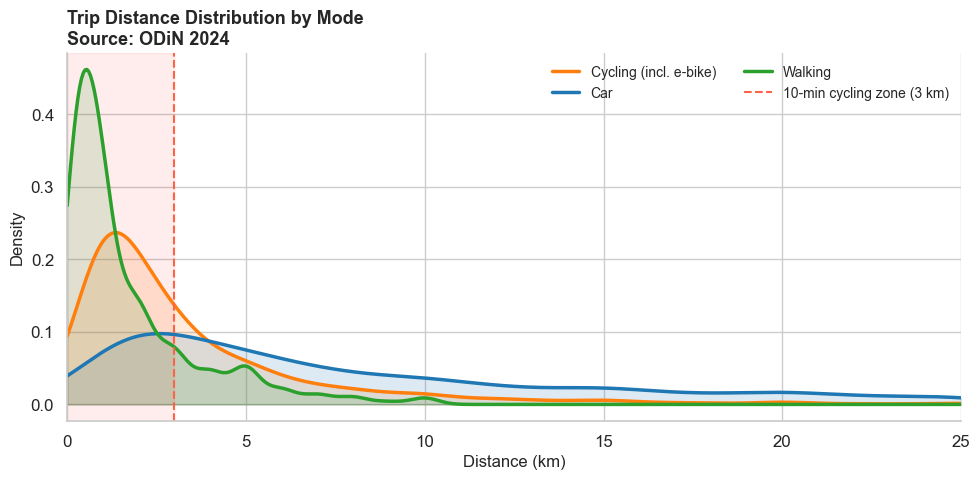

In [27]:
# Figure 2: Trip distance distribution by mode of transport
fig, ax = plt.subplots(figsize=(10, 5))
# using KDE because a raw histogram is hard to compare across modes because of the different trip counts, kde normalizes
# Setting up distances to evaluate KDE over 0 to 25km smooth curve
x = np.linspace(0, 25, 500)

# car and cycling cap at 25km walking at 10. 
for mask, lbl, col in [
    (df_trips['is_bike'] & (df_trips['dist_km'] <= 25), 'Cycling (incl. e-bike)', COLORS[1]),
    (df_trips['is_car']  & (df_trips['dist_km'] <= 25), 'Car', COLORS[0]),
    (df_trips['is_walk'] & (df_trips['dist_km'] <= 10), 'Walking', COLORS[2]),
]:
    # Extracting distances and dropping rows which dont have distance
    vals = df_trips.loc[mask, 'dist_km'].dropna().values
    # Fit kernel density estimator to the distance values ( creating guassian curve)
    kde  = gaussian_kde(vals, bw_method=0.2)
    ax.plot(x, kde(x), color=col, lw=2.5, label=lbl)
    ax.fill_between(x, kde(x), alpha=0.15, color=col)

ax.axvspan(0, 3.0,  alpha=0.07, color='red')
ax.axvline(3.0,  ls='--', color='tomato', lw=1.5, label='10-min cycling zone (3 km)')

ax.set_xlabel('Distance (km)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Trip Distance Distribution by Mode\nSource: ODiN 2024',
             fontsize=13, fontweight='bold', loc='left')
ax.legend(frameon=False, fontsize=10, ncol=2, loc='upper right')
ax.set_xlim(0, 25)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('images/fig2_distance_dist.png', dpi=150)
plt.show()

> **📌 Extra figure — not yet in Report:** Cycling trip time distribution  
> Shows what share of cycling trips falls within the 10-minute threshold. Consider adding to the report as additional validation of the time-based isochrone definition.

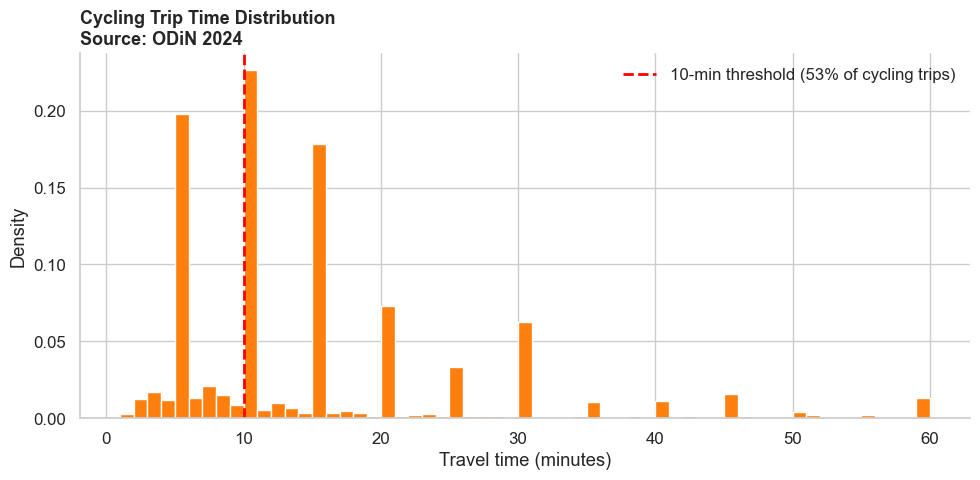

In [28]:
# Figure 8: Cycling trip time distribution
fig, ax = plt.subplots(figsize=(10, 5))
# new dataframe that is cycling and trip time
bt = df_trips[df_trips['is_bike'] & df_trips['Reisduur'].between(1, 60)]
# Percentage of trips within 10 minutes
pct = np.average(bt['within10min'], weights=bt['wV']) * 100
ax.hist(bt['Reisduur'], bins=range(1, 61), weights=bt['wV'],
        color=COLORS[1], edgecolor='white', alpha=1, density=True)
# Vline at 10 min treshold
ax.axvline(10, ls='--', color='red', lw=2,
           label=f'10-min threshold ({pct:.0f}% of cycling trips)')
ax.set_xlabel('Travel time (minutes)')
ax.set_ylabel('Density')
ax.set_title('Cycling Trip Time Distribution\nSource: ODiN 2024', fontsize=13, fontweight='bold', loc='left')
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('images/fig8_time_dist.png', dpi=150)
plt.show()

##### Figure 1.2 — Distance decay curves by bike type and trip purpose

*Corresponds to Report Figure 1.2.* Shows how willingness to cycle declines with distance, split by bike type (regular vs. e-bike) and trip purpose (work, education, grocery shopping). E-bikes extend the practical range beyond the 3 km threshold.

In [29]:
# TODO — Figure 1.2: Distance decay by bike type and trip purpose — CODE MISSING
# ⚠️ This figure appears in the Report (Section 1.2.2) but the code is missing from the notebook.
# Add the code here to generate this figure.
pass

##### Figure 1.3 — Bike type share by age group

*Corresponds to Report Figure 1.3.* Younger travellers predominantly use regular bicycles; older travellers shift toward e-bikes.

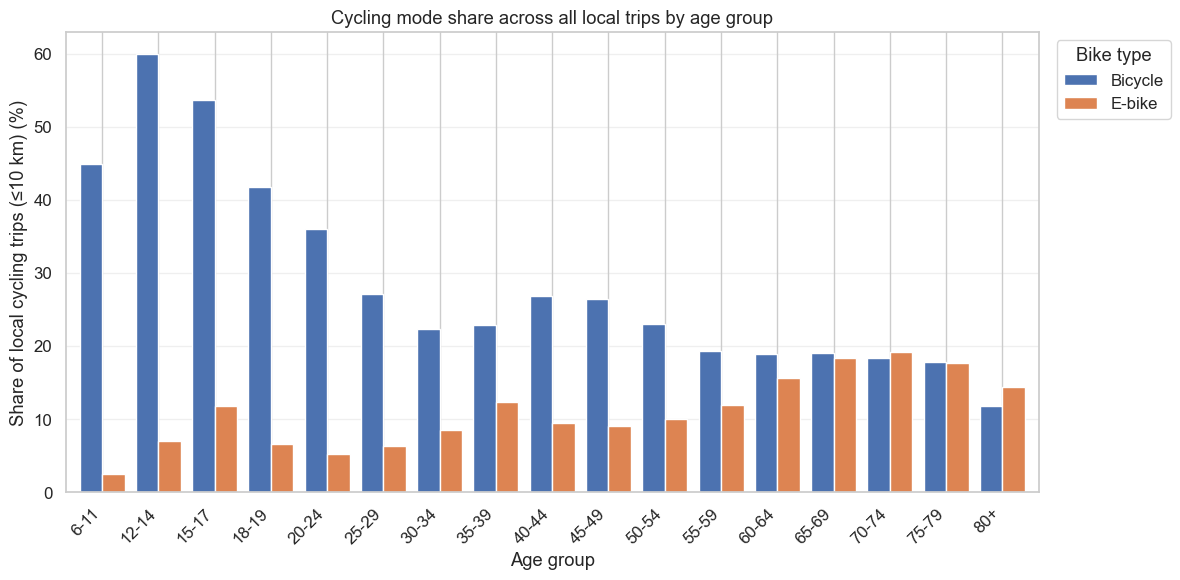

In [30]:
# Figure 7: Bike type x target age

# Labels from codebook
age_labels = {
    2: '6-11', 3: '12-14', 4: '15-17', 5: '18-19',
    6: '20-24', 7: '25-29', 8: '30-34', 9: '35-39',
    10: '40-44', 11: '45-49', 12: '50-54', 13: '55-59',
    14: '60-64', 15: '65-69', 16: '70-74', 17: '75-79',
    18: '80+'
}

bike_labels = {
    6: 'Speed pedelec',
    7: 'E-bike',
    8: 'Bicycle'
}

df_trips['age_group'] = df_trips['KLeeft'].map(age_labels)
df_trips['bike_type'] = df_trips['Hvm'].map(bike_labels)

# all trips within 3km
all_trips = df_trips[df_trips['within3km']].copy()
all_trips['age_group'] = all_trips['KLeeft'].map(age_labels)

# only bike trips within 3km
bike_age = df_trips[df_trips['within3km'] & df_trips['bike_type'].notna()].copy()

grouped = (
    bike_age
    .groupby(['age_group', 'bike_type'], observed=True)
    ['wV'].sum()
    .reset_index(name='count')
)

total_by_age = (
    all_trips
    .groupby('age_group', observed=True)
    ['wV'].sum()
    .reset_index(name='total')
)

grouped = grouped.merge(total_by_age, on='age_group')
grouped['share_pct'] = grouped['count'] / grouped['total'] * 100

pivot = grouped.pivot(index='age_group', columns='bike_type', values='share_pct').fillna(0)

age_order = list(age_labels.values())
pivot = pivot.reindex(age_order).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
pivot.plot(kind='bar', ax=ax, width=0.8)

ax.set_xlabel('Age group')
ax.set_ylabel('Share of local cycling trips (≤10 km) (%)')
ax.set_title('Cycling mode share across all local trips by age group')
ax.legend(title='Bike type', bbox_to_anchor=(1.01, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('images/fig7_biketype_agegroup.png', dpi=150)
plt.show()

##### Figure 1.4 — Trip purpose: cycling vs. car

*Corresponds to Report Figure 1.4.* Cycling is used far more often than the car for education trips, underlining the importance of accessible schools within the cycling radius.

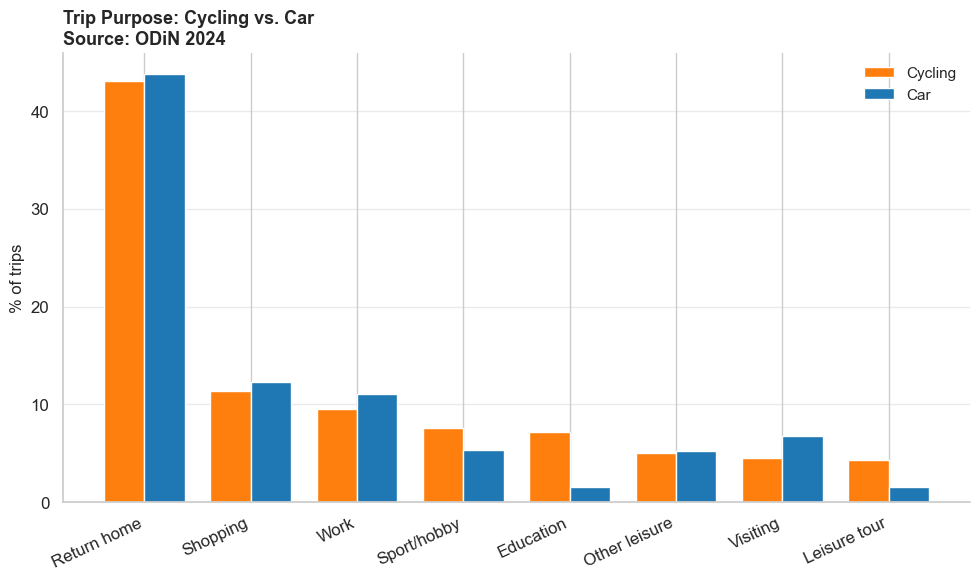

In [31]:
# Figure 6: Trip purpose bike vs car
doel_map = {1:'Return home', 2:'Work', 3:'Business visit', 4:'Professional',
            5:'Pick up/drop off person', 6:'Pick up/drop off goods',
            7:'Education', 8:'Shopping', 9:'Visiting', 10:'Leisure tour',
            11:'Sport/hobby', 12:'Other leisure', 13:'Personal services', 14:'Other'}
df_trips['doel_label'] = df_trips['Doel'].map(doel_map)

bike_purpose = df_trips[df_trips['is_bike']].groupby('doel_label')['wV'].sum()
bike_purpose = bike_purpose / bike_purpose.sum() * 100
car_purpose  = df_trips[df_trips['is_car']].groupby('doel_label')['wV'].sum()
car_purpose  = car_purpose / car_purpose.sum() * 100
# taking 8 biggest purposes
top_purposes = bike_purpose.nlargest(8).index
comp = pd.DataFrame({'Cycling': bike_purpose.reindex(top_purposes).fillna(0),
                     'Car':     car_purpose.reindex(top_purposes).fillna(0)})

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(top_purposes)); w = 0.38
ax.bar(x - w/2, comp['Cycling'], width=w, label='Cycling', color=COLORS[1], edgecolor='white')
ax.bar(x + w/2, comp['Car'],     width=w, label='Car',     color=COLORS[0], edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(top_purposes, rotation=25, ha='right')
ax.set_ylabel('% of trips', fontsize=12)
ax.set_title('Trip Purpose: Cycling vs. Car\nSource: ODiN 2024',
             fontsize=13, fontweight='bold', loc='left')
ax.legend(frameon=False, fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('images/fig6_purpose_bike_vs_car.png', dpi=150)
plt.show()

---

#### Results — Research Question 1

Geographic variation in 10-minute cycling access and local cycling usage across Dutch municipalities and provinces.

##### Figure 1.5 — Share of local cycling trips by province

*Corresponds to Report Figure 1.5.* Zeeland has the highest share of cycling trips within 3 km; Limburg the lowest.

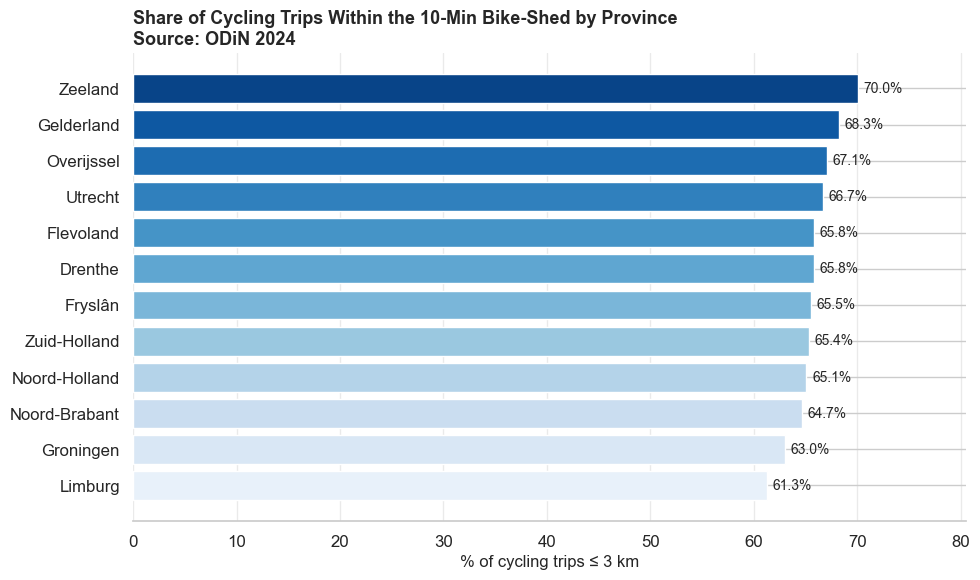

In [32]:
# Figure 5: Local cycling rate by province
prov_local = (
    df_trips[df_trips['is_bike']]
    .groupby('prov_label', observed=True)
    .apply(lambda g: np.average(g['within3km'], weights=g['wV']) * 100)
    .sort_values(ascending=False)
    .reset_index(name='pct_within3km')
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(prov_local['prov_label'], prov_local['pct_within3km'],
               color=sns.color_palette('Blues_r', len(prov_local)), edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=10)
ax.set_xlabel('% of cycling trips ≤ 3 km', fontsize=12)
ax.invert_yaxis()
ax.set_title('Share of Cycling Trips Within the 10-Min Bike-Shed by Province\n'
             'Source: ODiN 2024',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xlim(0, prov_local['pct_within3km'].max() * 1.15)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('images/fig5_local_biking_province.png', dpi=150)
plt.show()

##### Figure 1.6 — Municipality ranking by 10-minute cycling access score

*Corresponds to Report Figure 1.6.* Top and bottom 10 municipalities ranked by mean `bike10_weighted_score` (CBS-based access). Haarlem, Leiden, Delft, Rijswijk and Amsterdam score highest; Nieuwkoop, Voorst and Tubbergen score lowest.

In [33]:
# TODO — Figure 1.6: Top & bottom municipalities by bike10_weighted_score (ACCESS ranking) — CODE MISSING
# ⚠️ This figure appears in the Report (Section 1.2.2) but the code is missing from the notebook.
# Add the code here to generate this figure.
pass

##### Figure 1.7 — Top and bottom municipalities by local cycling usage

*Corresponds to Report Figure 1.7.* Top and bottom 10 municipalities ranked by share of cycling trips ≤ 3 km (ODiN-based usage). None of the top-10 access municipalities appear here, illustrating the access–usage gap.

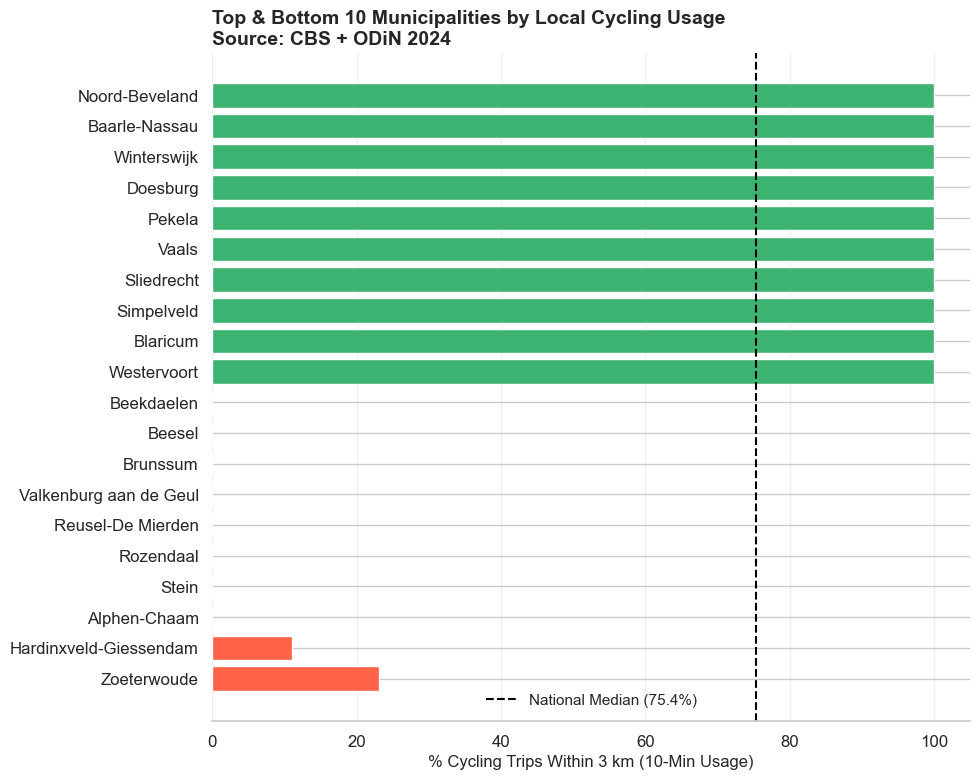

In [34]:
# Aggregate USAGE to the municipality level
mun_usage = (df_paired.groupby('gm_naam', observed=True)['pct_within_3km']
             .mean().sort_values())

# Extract Top 10 and Bottom 10
bottom10 = mun_usage.head(10)
top10    = mun_usage.tail(10).sort_values(ascending=False)
ranked_usage = pd.concat([top10, bottom10])

colors = ['mediumseagreen'] * 10 + ['tomato'] * 10 

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(ranked_usage.index, ranked_usage.values, color=colors, edgecolor='white')

# Add the national median line for benchmarking
national_median = mun_usage.median()
ax.axvline(national_median, ls='--', color='black', lw=1.5, 
           label=f'National Median ({national_median:.1f}%)')

ax.set_xlabel('% Cycling Trips Within 3 km (10-Min Usage)', fontsize=12)
ax.set_title('Top & Bottom 10 Municipalities by Local Cycling Usage\nSource: CBS + ODiN 2024',
             fontsize=14, fontweight='bold', loc='left')
ax.legend(frameon=False, fontsize=11)
ax.spines[['top','right','left']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis() 

plt.tight_layout()
plt.savefig('images/fig19_top_bottom_usage_mun.png', dpi=150)
plt.show()

##### Figure 1.8 — Spatial comparison: 10-minute bike access and cycling usage per municipality

*Corresponds to Report Figure 1.8.* Side-by-side choropleth maps showing that high access and high usage do not always coincide spatially.

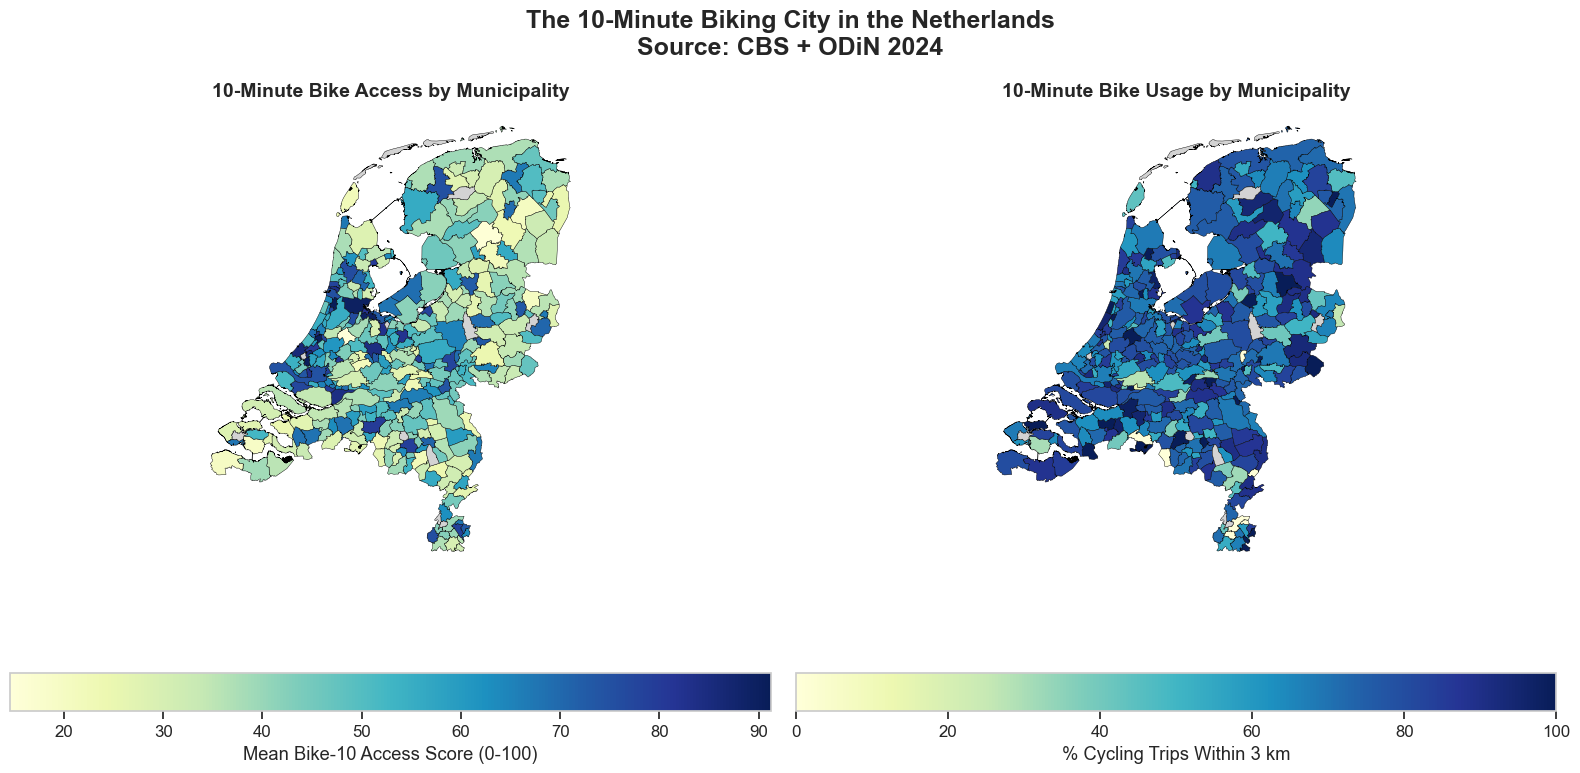

In [35]:
import geopandas as gpd

mun_macro = df_paired.groupby('gm_naam', observed=True).agg(
    mean_access=('bike10_weighted_score', 'mean'),
    mean_usage=('pct_within_3km', 'mean'),
    total_pop=('a_inw', 'sum')
).dropna().reset_index()

gdf_mun = gpd.read_file("Data/CBS/wijkenbuurten_2025_v1.gpkg", layer='gemeenten')

# Filter out large bodies of water so the map looks like the actual Netherlands
if 'water' in gdf_mun.columns:
    gdf_mun = gdf_mun[gdf_mun['water'] == 'NEE']

# Merge data into the GeoDataFrame
gdf_mapped = gdf_mun.merge(mun_macro, left_on='gemeentenaam', right_on='gm_naam', how='left')

# Create a side-by-side map layout
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Map 1: Access Score (Blue/Green palette)
gdf_mapped.plot(column='mean_access', ax=axes[0], cmap='YlGnBu', 
                legend=True, legend_kwds={'label': "Mean Bike-10 Access Score (0-100)", 'orientation': "horizontal"},
                missing_kwds={'color': 'lightgrey', 'label': 'No Data'}, 
                edgecolor='black', linewidth=0.3) # Darker, thinner borders look professional

axes[0].set_title('10-Minute Bike Access by Municipality', fontsize=14, fontweight='bold')
axes[0].axis('off') # Hides the latitude/longitude axes

# Map 2: Usage Percentage (Red/Yellow/Green palette)
gdf_mapped.plot(column='mean_usage', ax=axes[1], cmap='YlGnBu', 
                legend=True, legend_kwds={'label': "% Cycling Trips Within 3 km", 'orientation': "horizontal"},
                missing_kwds={'color': 'lightgrey'}, 
                edgecolor='black', linewidth=0.3)

axes[1].set_title('10-Minute Bike Usage by Municipality', fontsize=14, fontweight='bold')
axes[1].axis('off')

fig.suptitle('The 10-Minute Biking City in the Netherlands\nSource: CBS + ODiN 2024', 
             fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout()
plt.savefig('images/fig21_geopandas_maps_cbs.png', dpi=300, bbox_inches='tight') 
plt.show()

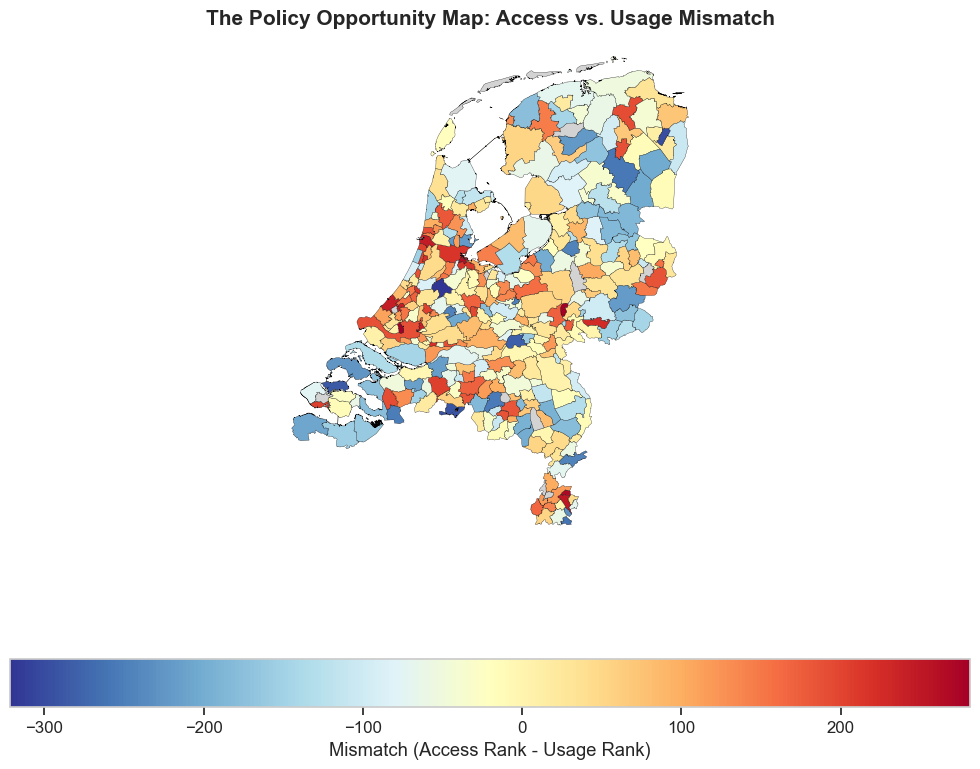

In [36]:
# Rank both variables from 1 to N (so they are on the exact same scale)
mun_macro['access_rank'] = mun_macro['mean_access'].rank()
mun_macro['usage_rank'] = mun_macro['mean_usage'].rank()

#Calculate the mismatch
# Positive gap = High Access but Low Usage (Underperforming)
# Negative gap = Low Access but High Usage (Overperforming)
mun_macro['mismatch_gap'] = mun_macro['access_rank'] - mun_macro['usage_rank']

# Merge with GeoDataFrame
gdf_mismatch = gdf_mun.merge(mun_macro, left_on='gemeentenaam', right_on='gm_naam', how='left')

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

# Blue = Cycling Outperforms Access | Red = Access Outperforms Cycling
gdf_mismatch.plot(column='mismatch_gap', ax=ax, cmap='RdYlBu_r', 
                  legend=True, legend_kwds={'label': "Mismatch (Access Rank - Usage Rank)", 'orientation': "horizontal"},
                  missing_kwds={'color': 'lightgrey'}, edgecolor='black', linewidth=0.2)

ax.set_title('The Policy Opportunity Map: Access vs. Usage Mismatch', fontsize=15, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('images/fig22_mismatch_map.png', dpi=300)
plt.show()

##### Figure 1.9 — High-detour municipalities: projected access gain under direct routing

*Corresponds to Report Figure 1.9.* Municipalities with the highest detour factors and largest projected access improvements if cycling routes were straightened. These are the most promising candidates for network investment.

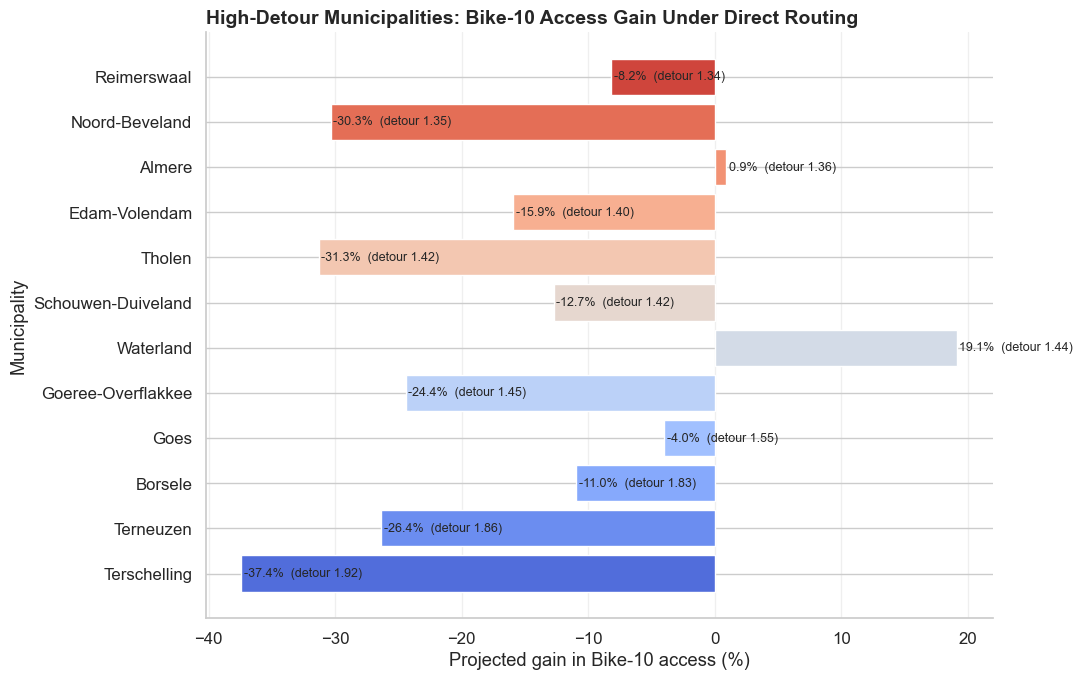

In [37]:
# Compare current bike-10 access with a direct-routing scenario
# Percent gain if detour rates could be reduced to straight-line routing

df_access['bike10_direct_gain_pct'] = np.where(
    df_access['bike10_weighted_score'] > 0,
    (df_access['bike10_direct_weighted_score'] - df_access['bike10_weighted_score'])
    / df_access['bike10_weighted_score'] * 100,
    np.nan
)

# Municipality-level summary for high-detour areas
mun_detour = (
    df_access.groupby('gm_naam', observed=True)
    .agg(
        mean_detour=('bike_detour_rate', 'mean'),
        mean_gain=('bike10_direct_gain_pct', 'mean'),
        n_buurten=('buurt_key', 'size')
    )
    .dropna()
    .query('n_buurten >= 5')
    .sort_values('mean_detour', ascending=False)
    .head(12)
)

fig, ax = plt.subplots(figsize=(11, 7))
colors = sns.color_palette('coolwarm', len(mun_detour))
bars = ax.barh(mun_detour.index, mun_detour['mean_gain'], color=colors, edgecolor='white')
for bar, detour in zip(bars, mun_detour['mean_detour']):
    width = bar.get_width()
    ax.text(width + 0.2, bar.get_y() + bar.get_height() / 2,
            f'{width:.1f}%  (detour {detour:.2f})', va='center', fontsize=9)

ax.set_xlabel('Projected gain in Bike-10 access (%)')
ax.set_title('High-Detour Municipalities: Bike-10 Access Gain Under Direct Routing', fontsize=14, fontweight='bold', loc='left')
ax.set_ylabel('Municipality')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('images/fig23_direct_routing_bike_gain.png', dpi=150)
plt.show()



> **📌 Extra figure — not yet in Report:** Access vs. usage scatter plot  
> Shows the correlation between `bike10_weighted_score` and `pct_within_3km` at neighbourhood level. Useful as quantitative support for the access–usage relationship discussed in the methods section.

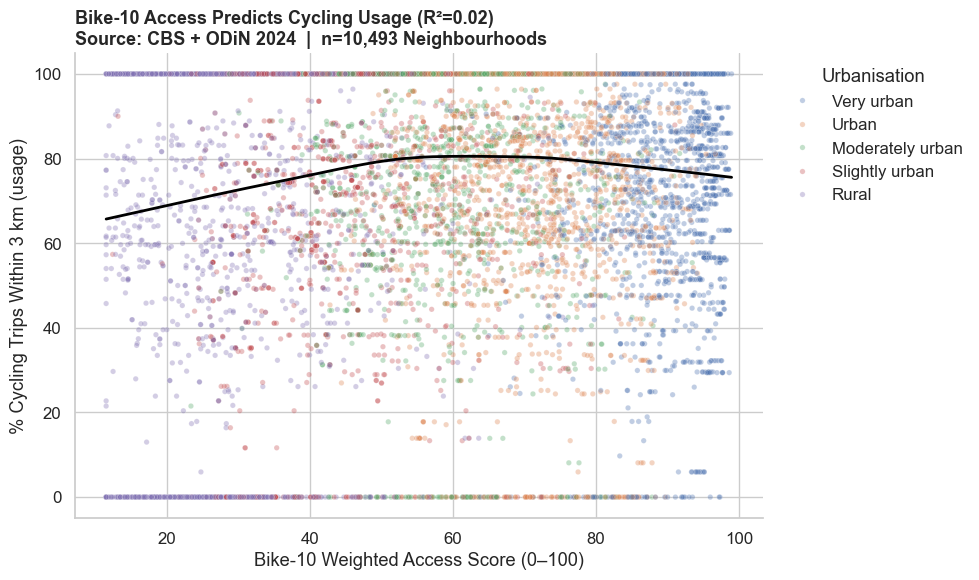

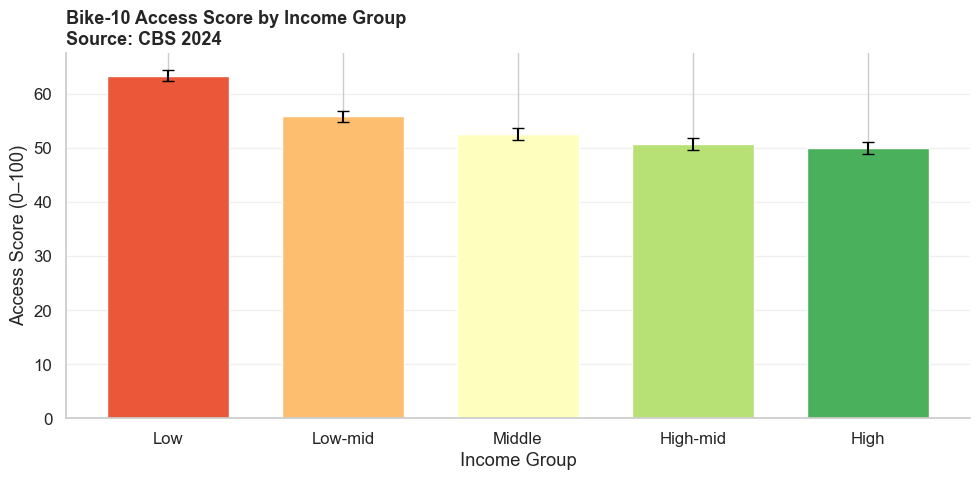

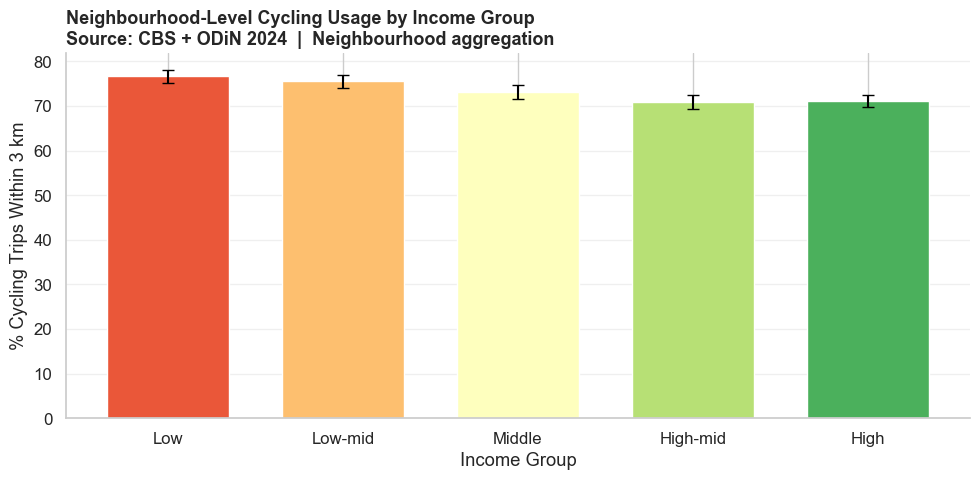

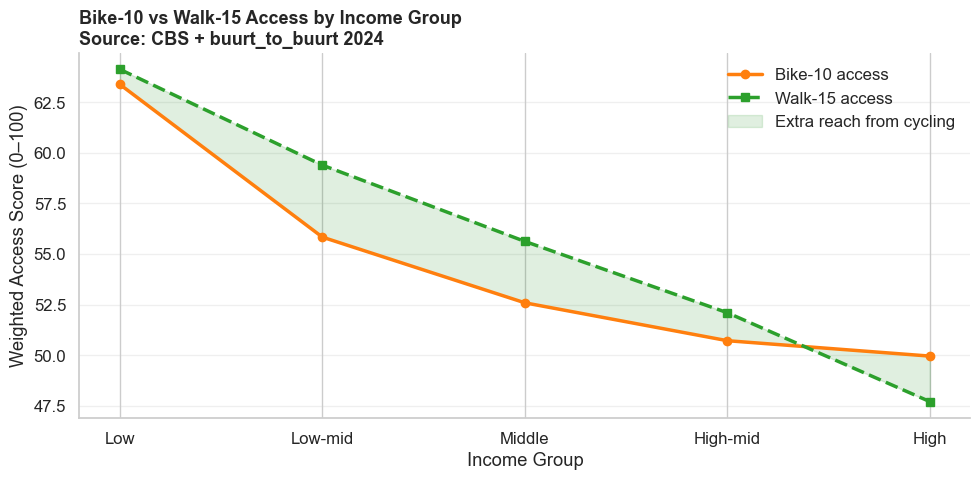

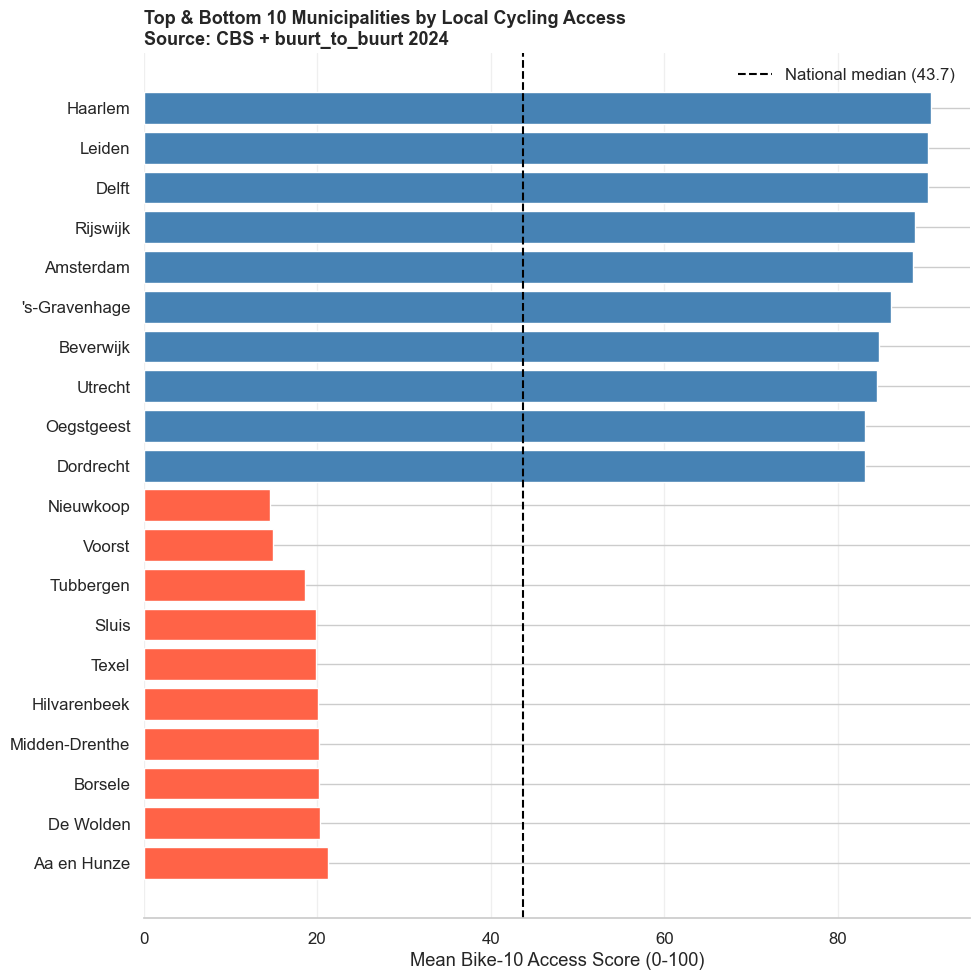

In [38]:
from scipy.stats import pearsonr

# Fig 13: Access predicts cycling usage
r2 = pearsonr(df_paired['bike10_weighted_score'], df_paired['pct_within_3km'])[0]**2

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df_paired, x='bike10_weighted_score', y='pct_within_3km',
                hue='stedelijkheid_label', alpha=0.35, s=15, ax=ax,
                hue_order=['Very urban','Urban','Moderately urban','Slightly urban','Rural'])
sns.regplot(data=df_access, x='bike10_weighted_score', y='pct_within_3km',
            scatter=False, lowess=True, color='black', line_kws={'lw':2}, ax=ax)
ax.set_title(f'Bike-10 Access Predicts Cycling Usage (R²={r2:.2f})\nSource: CBS + ODiN 2024  |  n={len(df_access):,} Neighbourhoods',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Bike-10 Weighted Access Score (0–100)')
ax.set_ylabel('% Cycling Trips Within 3 km (usage)')
ax.legend(title='Urbanisation', bbox_to_anchor=(1.01,1), frameon=False)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('images/fig13_access_usage_scatter.png', dpi=150)
plt.show()

# Fig 14: Bike-10 access by income decile
acc_dec = (df_access.groupby('income_decile', observed=True)['bike10_weighted_score']
           .agg(['mean','sem']).reset_index())
acc_dec['ci95'] = acc_dec['sem'] * 1.96


fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(acc_dec['income_decile'], acc_dec['mean'],
              color=sns.color_palette('RdYlGn', len(acc_dec)), edgecolor='white', width=0.7)
ax.errorbar(acc_dec['income_decile'], acc_dec['mean'],
            yerr=acc_dec['ci95'], fmt='none', color='black', capsize=4)
ax.set_title('Bike-10 Access Score by Income Group \nSource: CBS 2024',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Income Group')
ax.set_ylabel('Access Score (0–100)')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('images/fig14_access_by_income.png', dpi=150)
plt.show()

# Fig 15: Neighbourhood-level cycling usage by income decile
use_dec = (df_paired.groupby('income_decile', observed=True)['pct_within_3km']
           .agg(['mean','sem']).reset_index())
use_dec['ci95'] = use_dec['sem'] * 1.96

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(use_dec['income_decile'], use_dec['mean'],
              color=sns.color_palette('RdYlGn', len(use_dec)), edgecolor='white', width=0.7)
ax.errorbar(use_dec['income_decile'], use_dec['mean'],
            yerr=use_dec['ci95'], fmt='none', color='black', capsize=4)
ax.set_title('Neighbourhood-Level Cycling Usage by Income Group\nSource: CBS + ODiN 2024  |  Neighbourhood aggregation',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Income Group')
ax.set_ylabel('% Cycling Trips Within 3 km')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('images/fig15_usage_by_income_buurt.png', dpi=150)
plt.show()

# Fig 16: Bike-10 vs Walk-15 access by income 
reach = (df_access.groupby('income_decile', observed=True)
         .agg(bike10=('bike10_weighted_score','mean'),
              walk15=('walk15_weighted_score','mean'))
         .reset_index())


fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(reach['income_decile'], reach['bike10'], marker='o', color=COLORS[1],
        lw=2.5, label='Bike-10 access')
ax.plot(reach['income_decile'], reach['walk15'], marker='s', color=COLORS[2],
        lw=2.5, linestyle='--', label='Walk-15 access')
ax.fill_between(reach['income_decile'], reach['walk15'], reach['bike10'],
                alpha=0.12, color='green', label='Extra reach from cycling')
ax.set_title('Bike-10 vs Walk-15 Access by Income Group \nSource: CBS + buurt_to_buurt 2024',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Income Group')
ax.set_ylabel('Weighted Access Score (0–100)')
ax.legend(frameon=False)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('images/fig16_bike_vs_walk_access.png', dpi=150)
plt.show()

# Fig 17: Top/bottom 10 municipalities by bike-10 access 
mun = (df_access.groupby('gm_naam', observed=True)['bike10_weighted_score']
       .mean().sort_values())
bottom10 = mun.head(10)
top10    = mun.tail(10).sort_values(ascending=False)
ranked   = pd.concat([top10, bottom10])
colors   = ['steelblue']*10 + ['tomato']*10

fig, ax = plt.subplots(figsize=(10, 10))
bars = ax.barh(ranked.index, ranked.values, color=colors, edgecolor='white')
ax.axvline(mun.median(), ls='--', color='black', lw=1.5, label=f'National median ({mun.median():.1f})')
ax.set_xlabel('Mean Bike-10 Access Score (0-100)')
ax.set_title('Top & Bottom 10 Municipalities by Local Cycling Access \nSource: CBS + buurt_to_buurt 2024',
             fontsize=13, fontweight='bold', loc='left')
ax.legend(frameon=False)
ax.spines[['top','right','left']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('images/fig17_municipality_ranking.png', dpi=150)
plt.show()

---

#### Results — Research Question 2

Income equity and urbanisation effects on 10-minute cycling access and local cycling behaviour.

##### Figure 1.10 — 10-minute cycling usage by household income group

*Corresponds to Report Figure 1.10.* The share of essential cycling trips within 3 km is broadly similar across income groups (~74%), suggesting local cycling behaviour is not strongly stratified by income.

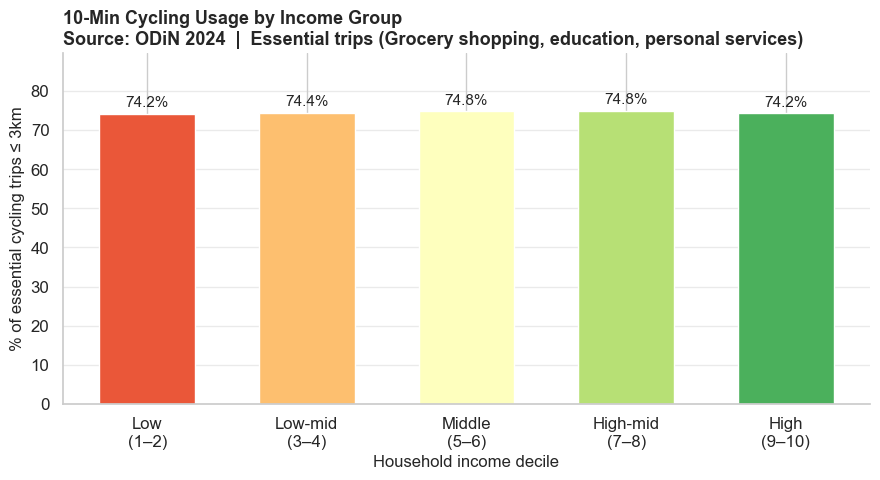

In [39]:
# Figure 3: local cycling on essential trips by income
inc_bike = (
    # Filtering by essential trips, only cycling and oonly known income groups
    df_trips[df_trips['is_essential'] & df_trips['is_bike'] & (df_trips['HHGestInkG'] <= 10)]
    .groupby('income_group', observed=True)
    .apply(lambda g: np.average(g['within3km'], weights=g['wV']) * 100)
    .reset_index(name='pct_bike_local')
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(inc_bike['income_group'].astype(str), inc_bike['pct_bike_local'],
              color=sns.color_palette('RdYlGn', len(inc_bike)), edgecolor='white', width=0.6)
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=11)
ax.set_xlabel('Household income decile', fontsize=12)
ax.set_ylabel('% of essential cycling trips ≤ 3km', fontsize=12)
ax.set_title('10-Min Cycling Usage by Income Group\n'
             'Source: ODiN 2024  |  Essential trips (Grocery shopping, education, personal services)',
             fontsize=13, fontweight='bold', loc='left')
ax.set_ylim(0, inc_bike['pct_bike_local'].max() * 1.2)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('images/fig3_bikeusage_income.png', dpi=150)
plt.show()

##### Figure 1.11 — Amenity coverage within the 10-minute cycling radius

*Corresponds to Report Figure 1.11.* Bus stops, primary schools, GP services, supermarkets and pharmacies are reachable for the large majority of neighbourhoods; hospitals and train stations are far less consistently accessible within the same radius.

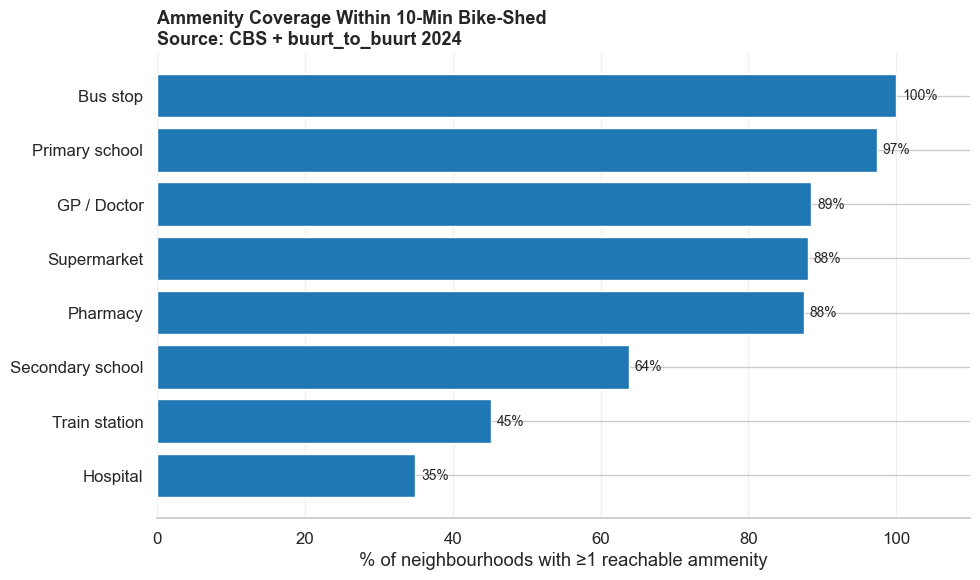

In [40]:
fac_labels = {
    'bike10_klasse_supermarkt': 'Supermarket',
    'bike10_klasse_huisarts': 'GP / Doctor',
    'bike10_klasse_basisschool': 'Primary school',
    'bike10_klasse_ziekenhuis': 'Hospital',
    'bike10_klasse_apotheek': 'Pharmacy',
    'bike10_klasse_voortgezet_onderwijs': 'Secondary school',
    'bike10_klasse_bushalte': 'Bus stop',
    'bike10_klasse_treinstation': 'Train station',
}
coverage = {lbl: (df_access[col] >= 1).mean() * 100
            for col, lbl in fac_labels.items() if col in df_access.columns}
cov = pd.Series(coverage).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(cov.index, cov.values, color=COLORS[0], edgecolor='white')
ax.bar_label(bars, fmt='%.0f%%', padding=4, fontsize=10)
ax.set_xlabel('% of neighbourhoods with ≥1 reachable ammenity')
ax.set_xlim(0, 110)
ax.set_title('Ammenity Coverage Within 10-Min Bike-Shed\n'
             'Source: CBS + buurt_to_buurt 2024',
             fontsize=13, fontweight='bold', loc='left')
ax.spines[['top','right','left']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('images/fig20_ammenity_coverage.png', dpi=150)

##### Figure 1.12 — Local cycling share by income group and urbanisation class (heatmap)

*Corresponds to Report Figure 1.12.* Two income groups can have similar national averages but differ substantially once urbanisation class is included, showing that spatial context shapes cycling patterns as much as income alone.

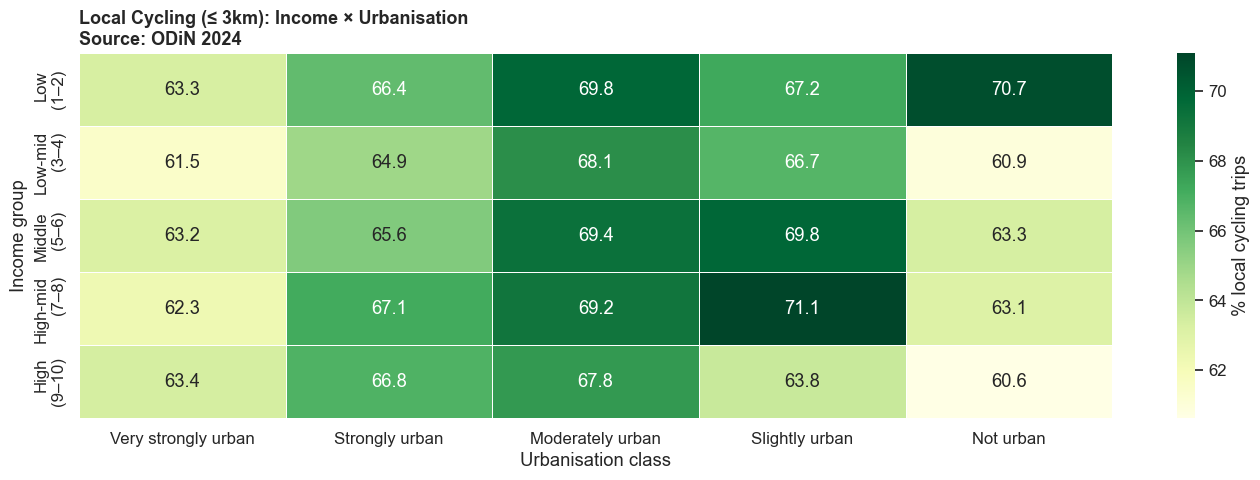

In [41]:
# Figure 10 heatmap of local cycling (within 10 min), income and urbanisation
heat = (df_trips[df_trips['HHGestInkG'].between(1,10) & df_trips['sted_label'].notna() & df_trips['is_bike']]
    .groupby(['income_group','sted_label'], observed=True)
    .apply(lambda g: np.average(g['within3km'], weights=g['wV']) * 100)
    .reset_index(name='pct'))

sted_order = ['Very strongly urban','Strongly urban','Moderately urban','Slightly urban','Not urban']
pivot = heat.pivot(index='income_group', columns='sted_label', values='pct')[sted_order]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlGn',
            linewidths=0.5, ax=ax, cbar_kws={'label':'% local cycling trips'})
ax.set_title('Local Cycling (≤ 3km): Income × Urbanisation\nSource: ODiN 2024',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Urbanisation class')
ax.set_ylabel('Income group')
plt.tight_layout()
plt.savefig('images/fig10_heatmap_income_urban.png', dpi=150)
plt.show()

##### Figure 1.13 — Bike-10 access score distribution by urbanisation class

*Corresponds to Report Figure 1.13.* More urban areas have higher and more consistent access scores; rural areas show lower scores and greater variation.

C:\Users\20192436\AppData\Local\Temp\ipykernel_23600\3240126914.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_access, x='stedelijkheid_label', y='bike10_weighted_score',


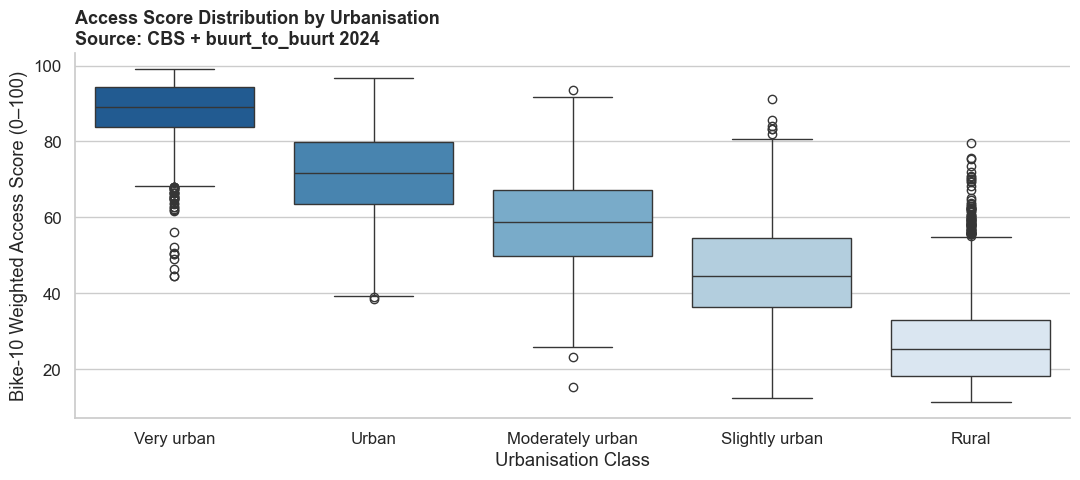

In [42]:
fig, ax = plt.subplots(figsize=(11, 5))
urban_order = ['Very urban', 'Urban', 'Moderately urban', 'Slightly urban', 'Rural']
sns.boxplot(data=df_access, x='stedelijkheid_label', y='bike10_weighted_score',
            order=urban_order, palette='Blues_r', ax=ax)
ax.set_title('Access Score Distribution by Urbanisation\n'
             'Source: CBS + buurt_to_buurt 2024', fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Urbanisation Class')
ax.set_ylabel('Bike-10 Weighted Access Score (0–100)')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('images/fig18_access_boxplot_urban.png', dpi=150)

##### Figure 1.14 — Modal split by urbanisation class

*Corresponds to Report Figure 1.14.* Car use increases as areas become less urban; cycling, walking and public transport play a larger role in dense urban environments.

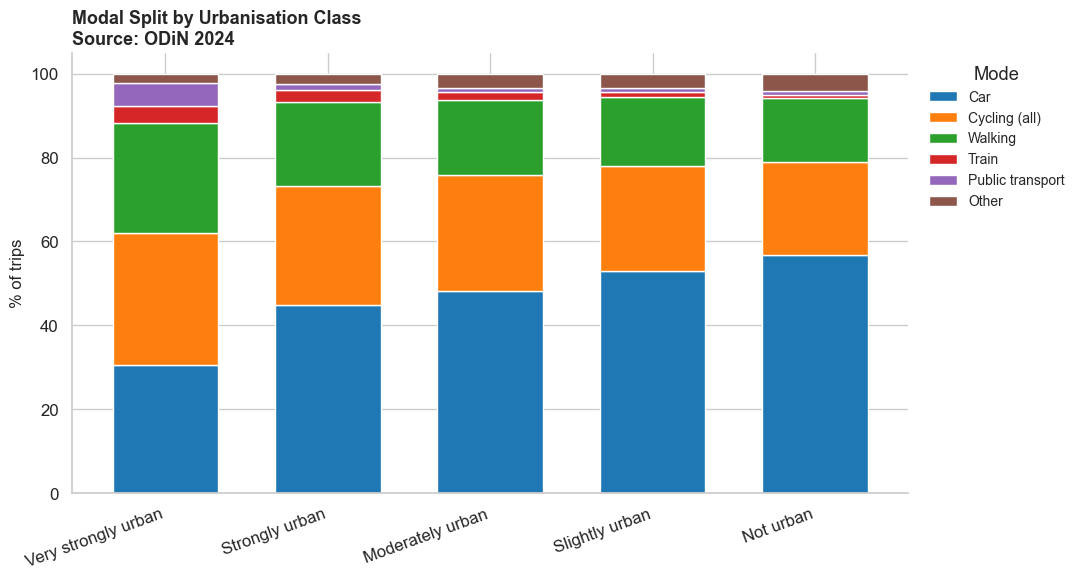

In [43]:
# Figure 4: Modal split by urbanisation
urban_mode = (
    df_trips.groupby(['sted_label', 'mode_simple'], observed=True)
    ['wV'].sum()
    .unstack(fill_value=0)
    # row wise normalize
    .apply(lambda r: r / r.sum() * 100, axis=1)
)

urban_order = ['Very strongly urban', 'Strongly urban', 'Moderately urban',
               'Slightly urban', 'Not urban']
col_order   = ['Car', 'Cycling (all)', 'Walking', 'Train', 'Public transport', 'Other']
urban_mode  = urban_mode.reindex(urban_order)[col_order]

fig, ax = plt.subplots(figsize=(11, 6))
urban_mode.plot(kind='bar', stacked=True, ax=ax,
                color=COLORS[:len(col_order)], edgecolor='white', width=0.65)
ax.set_xlabel('')
ax.set_ylabel('% of trips', fontsize=12)
ax.set_title('Modal Split by Urbanisation Class\nSource: ODiN 2024',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xticklabels(urban_order, rotation=20, ha='right')
ax.legend(title='Mode', bbox_to_anchor=(1.01, 1), frameon=False, fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('images/fig4_modal_urbanisation.png', dpi=150)
plt.show()

##### Figure 1.15 — Bike-10 access score by income group

*Corresponds to Report Figure 1.15.* Central equity figure for RQ2: shows whether lower-income groups have lower access to essential amenities within the 10-minute cycling radius, or whether denser urban location offsets the difference.

In [44]:
# TODO — Figure 1.15: Bike-10 access score by income group (bar chart with error bars) — CODE MISSING
# ⚠️ This figure appears in the Report (Section 1.2.2) but the code is missing from the notebook.
# Add the code here to generate this figure.
pass

---

## 1.3 Discussion

> See Report Section 1.3 for the full discussion.

Key findings:
- The 10-minute cycling city is a useful threshold, but high access does not guarantee high usage.
- Urbanisation is the strongest contextual factor shaping both access and behaviour.
- Income groups differ little in cycling usage rates, but differ in access levels (Figure 1.15).
- Policy interventions must be tailored to the type of mismatch: spatial access gaps vs. behavioural barriers.

## 1.3 Discussion

The figures below support the interpretation of the main results and keep the notebook aligned with the structure of the Report. Where the report text is not final yet, the notebook keeps the analytical block in place and marks the write-up need explicitly.


---


### Additional figure: National modal split

> *Not yet in Report.* Provides national travel mode context. Could be useful in the introduction or methods section to set the scene.

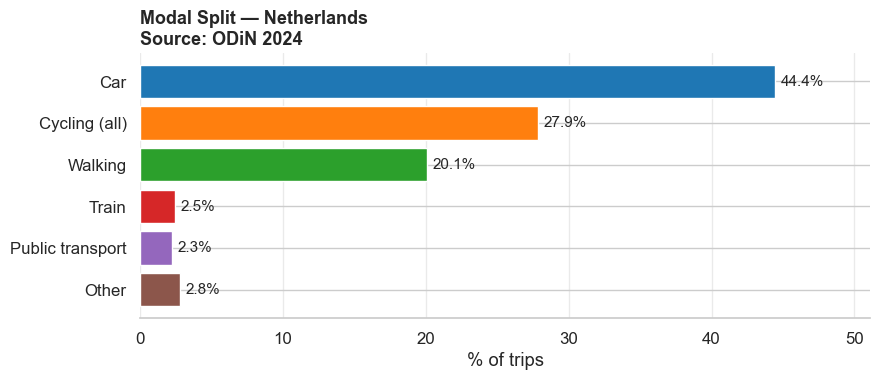

In [45]:
# Figure 1: Modal split: Overall travel mode distribution.

# Setting order for plot
order  = ['Car', 'Cycling (all)', 'Walking', 'Train', 'Public transport', 'Other']

# Weighting by weight factor
weighted = df_trips.groupby('mode_simple')['wV'].sum()
shares = weighted / weighted.sum() * 100
shares = shares.reindex(order)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(shares.index, shares.values, color=COLORS[:len(order)], edgecolor='white')
ax.bar_label(bars, fmt='%.1f%%', padding=4, fontsize=11)
ax.set_xlabel('% of trips')
ax.set_xlim(0, shares.max() * 1.15)
ax.invert_yaxis()
ax.set_title('Modal Split — Netherlands\nSource: ODiN 2024',
             fontsize=13, fontweight='bold', loc='left')
ax.grid(axis='x', alpha=0.4)
ax.spines[['top', 'right', 'left']].set_visible(False)
plt.tight_layout()
plt.savefig('images/fig1_modal_split.png', dpi=150)
plt.show()

### Additional figure: Modal split by income group

> *Not yet in Report.* Shows whether income groups differ structurally in transport mode choice. Potentially relevant for RQ2 as background context.

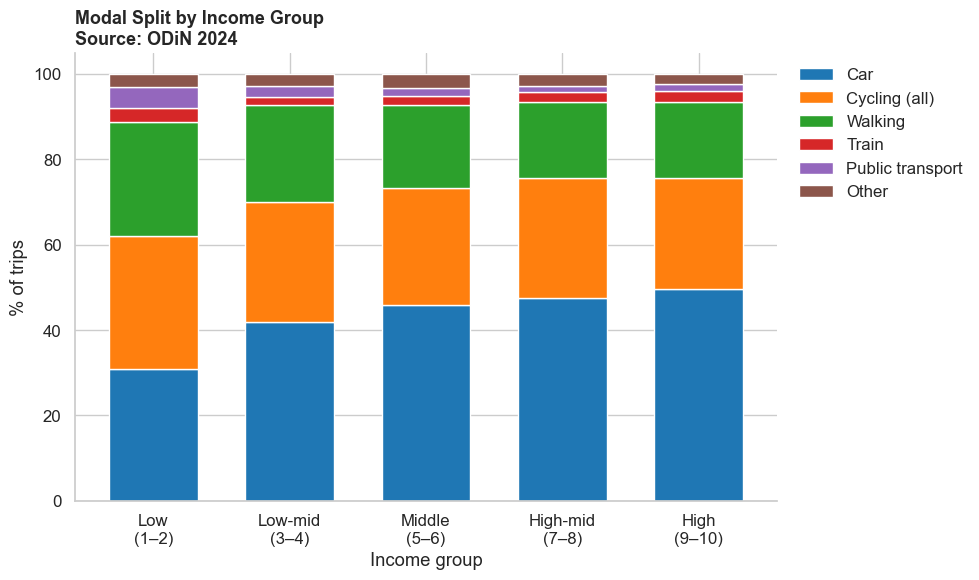

In [46]:
# Figure 9: Modal split by income group
ms_inc = (
    df_trips[df_trips['mode_simple'].notna() & df_trips['HHGestInkG'].between(1, 10)]
    .groupby(['income_group', 'mode_simple'], observed=True)['wV'].sum()
    .unstack(fill_value=0)
    .apply(lambda r: r / r.sum() * 100, axis=1)   # normalise within each income group
)[order]

fig, ax = plt.subplots(figsize=(10, 6))
ms_inc.plot(kind='bar', stacked=True, ax=ax, color=COLORS[:len(order)],
            edgecolor='white', width=0.65)
ax.set_ylabel('% of trips')
ax.set_xlabel('Income group')
ax.set_title('Modal Split by Income Group\nSource: ODiN 2024',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xticklabels(ms_inc.index, rotation=0)
ax.legend(bbox_to_anchor=(1.01, 1), frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('images/fig9_modal_income.png', dpi=150)
plt.show()

### Additional figure: Local cycling rate by age group

> *Not yet in Report.* Complements Figure 1.3 (bike type by age). Shows which age groups keep their cycling trips most local.

C:\Users\20192436\AppData\Local\Temp\ipykernel_23600\3842761654.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(age_order_full, rotation=45, ha='right')


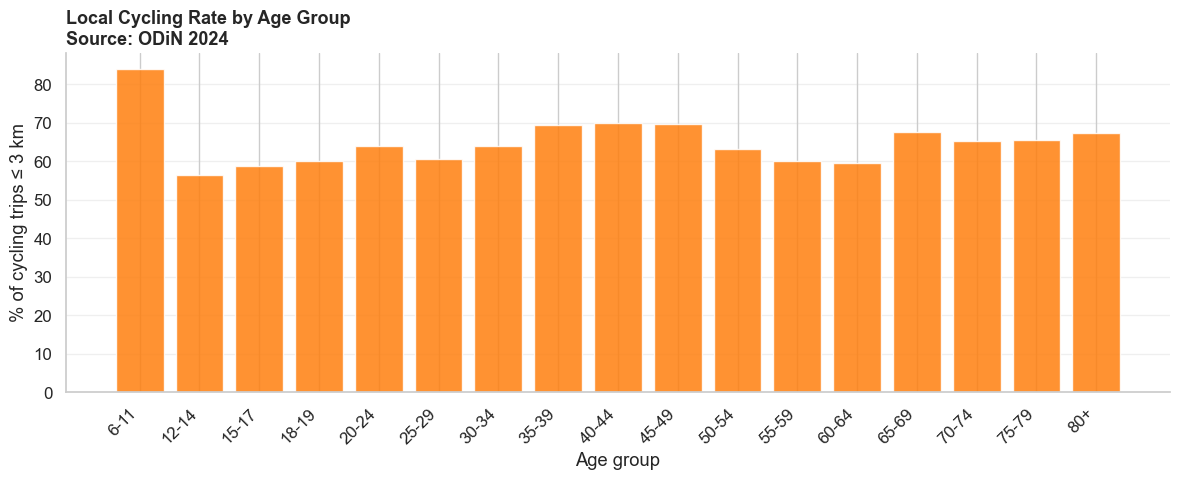

In [47]:
# Figure 11: Local cycling rate by age group
age_order_full = list(age_labels.values())
age_local = (df_trips[df_trips['is_bike'] & df_trips['age_group'].notna()]
    .groupby('age_group', observed=True)
    .apply(lambda g: np.average(g['within3km'], weights=g['wV']) * 100)
    .reindex(age_order_full))

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(age_local.index, age_local.values, color=COLORS[1], edgecolor='white', alpha=0.85)
ax.set_xlabel('Age group')
ax.set_ylabel('% of cycling trips ≤ 3 km')
ax.set_title('Local Cycling Rate by Age Group\nSource: ODiN 2024',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xticklabels(age_order_full, rotation=45, ha='right')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('images/fig11_local_cycling_age.png', dpi=150)
plt.show()

### Additional figure: Bike type share by societal participation group

> *Not yet in Report.* Shows which bike type (regular, e-bike, speed pedelec) is used most by each participation group (student, retired, employed, etc.) for local trips.

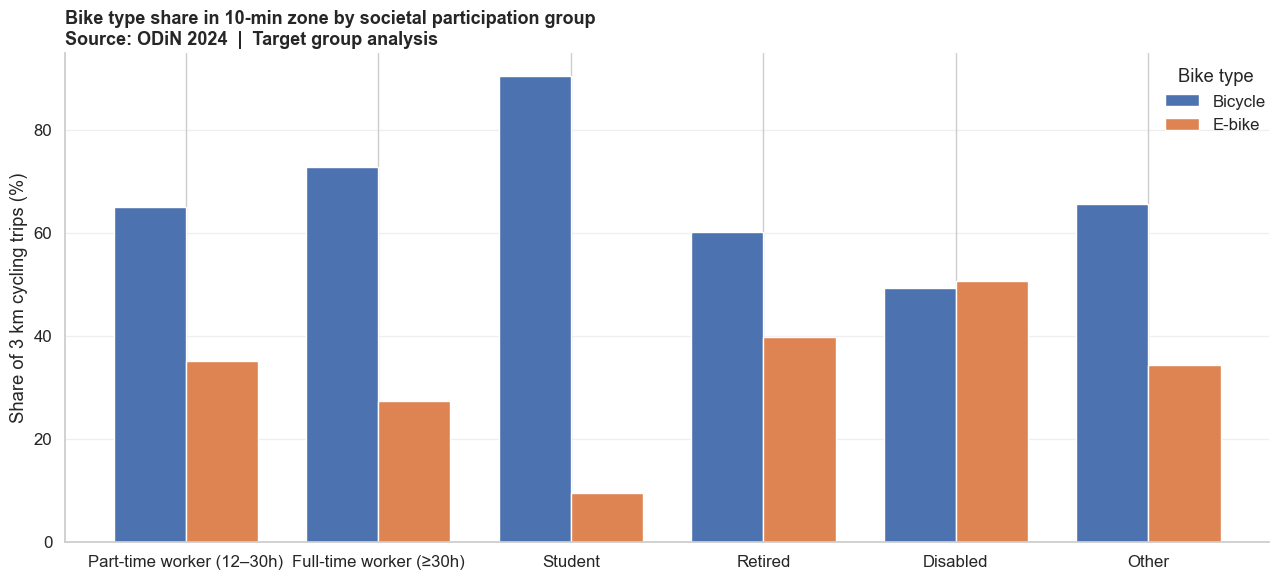

In [48]:
# Figure 12: Bike type x target group
maats_map = {
    1: 'Part-time worker (12–30h)',
    2: 'Full-time worker (≥30h)',
    3: 'Student',
    4: 'Retired',
    5: 'Disabled',
    6: 'Other'
}
maats_order = list(maats_map.values())
df_trips['maats_label'] = df_trips['MaatsPart_DANS24'].map(maats_map) 

# Only grouping local trips and known bike types and target group
bike_maats = df_trips[df_trips['within3km'] & df_trips['bike_type'].notna() & df_trips['maats_label'].notna()].copy()

grouped = (
    bike_maats
    .groupby(['maats_label', 'bike_type'], observed=True)
    ['wV'].sum()
    .reset_index(name='count')
)
totals = bike_maats.groupby('maats_label', observed=True)['wV'].sum().reset_index(name='total')
grouped = grouped.merge(totals, on='maats_label')
grouped['share_pct'] = grouped['count'] / grouped['total'] * 100

pivot = (grouped
    .pivot(index='maats_label', columns='bike_type', values='share_pct')
    .fillna(0)
    .reindex(maats_order)
)

fig, ax = plt.subplots(figsize=(13, 6))
pivot.plot(kind='bar', ax=ax, width=0.75, edgecolor='white')
ax.set_ylabel('Share of 3 km cycling trips (%)')
ax.set_xlabel('')
ax.set_title('Bike type share in 10-min zone by societal participation group\n'
             'Source: ODiN 2024  |  Target group analysis',
             fontsize=13, fontweight='bold', loc='left')
ax.set_xticklabels(maats_order, rotation=0, ha='center')
ax.legend(title='Bike type', bbox_to_anchor=(1.01, 1), frameon=False)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('images/fig12_biketype_participation.png', dpi=150)
plt.show()

### Additional figure: SES analysis — education × income × participation

> *Not yet in Report.* Broader socioeconomic status analysis. For internal use; evaluate before including in the report.

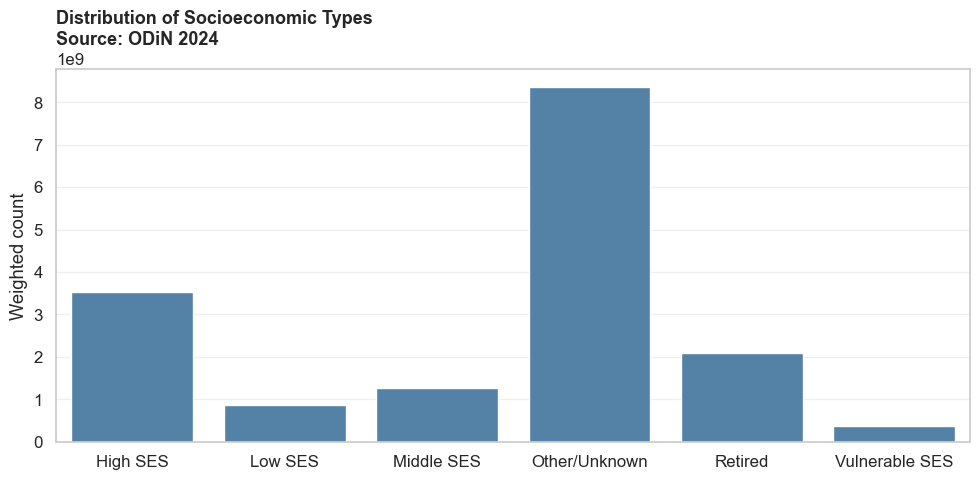

In [49]:
# Education
edu_map = {
    1: 'Low education',
    2: 'Medium education',
    3: 'High education',
    4: None,
    5: None
}
df_trips['edu_label'] = df_trips['Opleiding_DANS24'].map(edu_map)

# Participation
maats_map = {
    1: 'Part-time worker',
    2: 'Full-time worker',
    3: 'Student',
    4: 'Disabled',
    5: 'Retired',
    6: 'Other'
}
df_trips['maats_label'] = df_trips['MaatsPart_DANS24'].map(maats_map)

df_trips['income_group'] = pd.cut(
    df_trips['HHGestInkG'],
    bins=[0, 2, 4, 6, 8, 10],
    labels=['Low (1–2)', 'Low-mid (3–4)', 'Middle (5–6)',
            'High-mid (7–8)', 'High (9–10)']
)


def classify_ses(row):
    edu = row['edu_label']
    inc = row['income_group']     # <-- use the label
    part = row['maats_label']
    
    if edu == 'High education' and inc in ['High (9–10)', 'High-mid (7–8)'] and part in ['Full-time worker', 'Part-time worker']:
        return 'High SES'
    if edu == 'Medium education' and inc in ['Middle (5–6)', 'Low-mid (3–4)'] and part in ['Full-time worker', 'Part-time worker', 'Student']:
        return 'Middle SES'
    if edu == 'Low education' and inc in ['Low (1–2)', 'Low-mid (3–4)']:
        return 'Low SES'
    if part == 'Disabled':
        return 'Vulnerable SES'
    if part == 'Retired':
        return 'Retired'
    return 'Other/Unknown'


df_trips['SES_type'] = df_trips.apply(classify_ses, axis=1)


ses_counts = (
    df_trips[df_trips['SES_type'].notna()]
    .groupby('SES_type')['FactorV']
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.barplot(data=ses_counts, x='SES_type', y='FactorV', color='steelblue')
plt.title('Distribution of Socioeconomic Types\nSource: ODiN 2024', fontsize=13, fontweight='bold', loc='left')
plt.ylabel('Weighted count')
plt.xlabel('')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

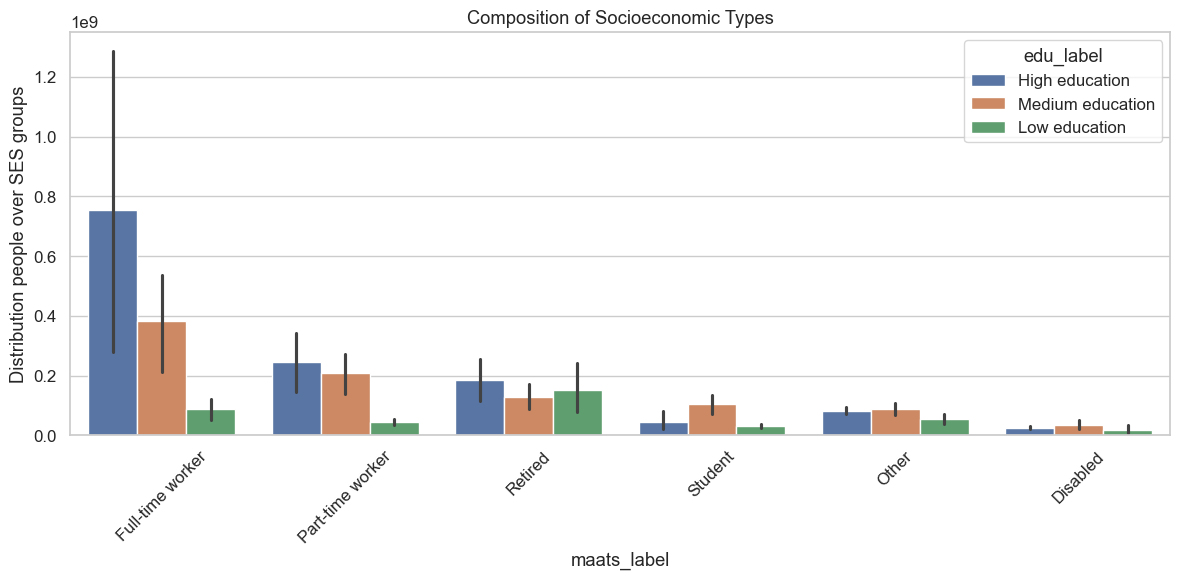

In [50]:
ses_all = (
    df_trips
    .groupby(['edu_label', 'income_group', 'maats_label'])['FactorV']
    .sum()
    .reset_index()
    .sort_values('FactorV', ascending=False)
)


plt.figure(figsize=(12,6))
sns.barplot(
    data=ses_all,
    x='maats_label',
    y='FactorV',
    hue='edu_label'
)
plt.title('Composition of Socioeconomic Types')
plt.xticks(rotation=45)
plt.tight_layout()
plt.ylabel("Distribution people over SES groups") #FactorV corrects for: sampling bias, non-response, demographic imbalance, regional difference
plt.show()

---

### Social exposure follow-up

This block supports the **Discussion** section in the Report and keeps the notebook aligned with the report structure.

**Current status:** the access and usage analyses above are already reflected in the Report structure. The social exposure analysis below remains an exploratory extension that can be folded into the report once the surrounding text is finalised.

> **TODO for report alignment:** decide whether to keep the fallback neighbourhood affluence proxy (`g_wozbag` when `g_ink_pi` coverage is too low) or replace it with a more complete neighbourhood income indicator.


In [51]:
coverage_table = (
    pd.Series(income_metric_coverage, name='valid_neighbourhoods')
    .sort_values(ascending=False)
    .to_frame()
)

print(f'Using {income_metric_col} as the neighbourhood affluence metric for social exposure.')
display(coverage_table)
display(dest_profile.head())


Using g_wozbag as the neighbourhood affluence metric for social exposure.


,valid_neighbourhoods
g_wozbag,12781
g_ink_pi,1950


,buurt_key,gm_naam,a_inw,g_wozbag,dest_income_group,dest_income_score
3,00140000,Groningen,4745,295.0,Low,1
4,00140001,Groningen,6975,274.0,Low,1
5,00140002,Groningen,4400,251.0,Low,1
6,00140003,Groningen,1740,274.0,Low,1
8,00140005,Groningen,6575,287.0,Low,1


In [52]:
# Merge the cached walk and bike social exposure tables back to the filtered neighbourhood dataframe
df_social_exposure = (
    df_access
    .merge(walk_exposure, on='buurt_key', how='left')
    .merge(bike_exposure, on='buurt_key', how='left')
)

df_social_exposure['diversity_gain_shannon'] = df_social_exposure['bike10_shannon_norm'] - df_social_exposure['walk15_shannon_norm']
df_social_exposure['diversity_gain_groups'] = df_social_exposure['bike10_n_income_groups'] - df_social_exposure['walk15_n_income_groups']
df_social_exposure['effective_group_gain'] = df_social_exposure['bike10_effective_income_groups'] - df_social_exposure['walk15_effective_income_groups']
df_social_exposure['reachable_pop_gain_pct'] = np.where(
    df_social_exposure['walk15_reachable_pop'] > 0,
    (df_social_exposure['bike10_reachable_pop'] - df_social_exposure['walk15_reachable_pop']) / df_social_exposure['walk15_reachable_pop'] * 100,
    np.nan
)
df_social_exposure['bike_expands_diversity'] = df_social_exposure['diversity_gain_shannon'] > 0

print(f'Social exposure analysis sample: {len(df_social_exposure):,} origin neighbourhoods')
print(f"Origins with valid walk exposure: {df_social_exposure['walk15_shannon_norm'].notna().sum():,}")
print(f"Origins with valid bike exposure: {df_social_exposure['bike10_shannon_norm'].notna().sum():,}")


Social exposure analysis sample: 10,493 origin neighbourhoods
Origins with valid walk exposure: 10,452
Origins with valid bike exposure: 10,491


In [53]:
# Direct summary for the RQ: does cycling expose residents to a broader socioeconomic mix?
summary_social_exposure = pd.Series({
    'mean_walk15_diversity': df_social_exposure['walk15_shannon_norm'].mean(),
    'mean_bike10_diversity': df_social_exposure['bike10_shannon_norm'].mean(),
    'mean_diversity_gain': df_social_exposure['diversity_gain_shannon'].mean(),
    'median_diversity_gain': df_social_exposure['diversity_gain_shannon'].median(),
    'share_origins_with_higher_bike_diversity_pct': df_social_exposure['bike_expands_diversity'].mean() * 100,
    'mean_walk15_effective_groups': df_social_exposure['walk15_effective_income_groups'].mean(),
    'mean_bike10_effective_groups': df_social_exposure['bike10_effective_income_groups'].mean(),
    'mean_reachable_pop_gain_pct': df_social_exposure['reachable_pop_gain_pct'].mean(),
})

print('Social exposure summary statistics:')
display(summary_social_exposure.to_frame('value'))


Social exposure summary statistics:


,value
mean_walk15_diversity,0.365508
mean_bike10_diversity,0.602419
mean_diversity_gain,0.237532
median_diversity_gain,0.208297
share_origins_with_higher_bike_diversity_pct,84.561136
mean_walk15_effective_groups,1.978377
mean_bike10_effective_groups,2.817853
mean_reachable_pop_gain_pct,446.298591


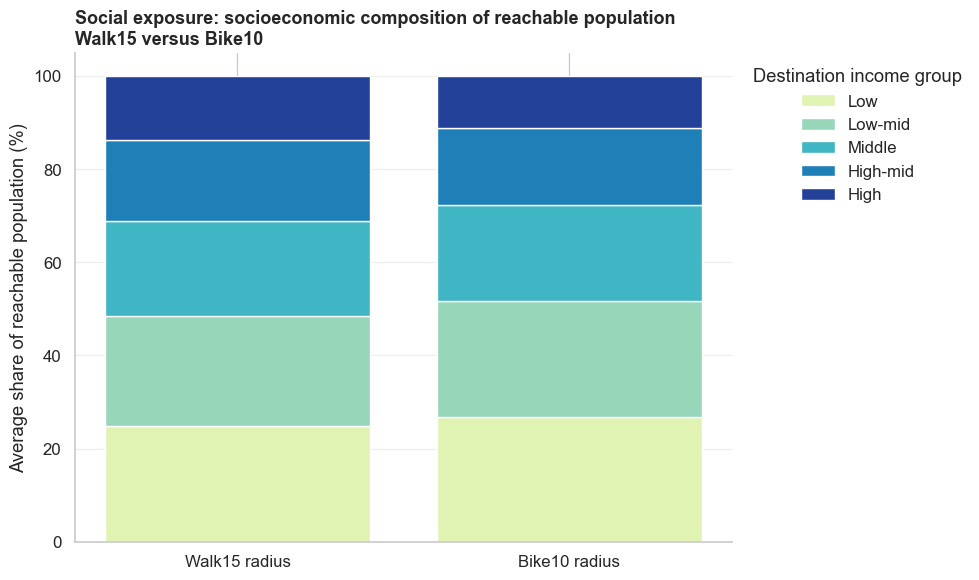

In [54]:
# Compare the average socioeconomic composition of the reachable population under walk15 and bike10
composition = pd.DataFrame({
    'walk15': [df_social_exposure[f'walk15_share_{income_slug_map[g]}'].mean() * 100 for g in income_order],
    'bike10': [df_social_exposure[f'bike10_share_{income_slug_map[g]}'].mean() * 100 for g in income_order],
}, index=income_order)

fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(2)
xlabels = ['Walk15 radius', 'Bike10 radius']
palette = sns.color_palette('YlGnBu', len(income_order))

for color, group in zip(palette, income_order):
    values = composition.loc[group].values
    ax.bar(xlabels, values, bottom=bottom, label=group, color=color, edgecolor='white')
    bottom = bottom + values

ax.set_ylabel('Average share of reachable population (%)')
ax.set_title('Social exposure: socioeconomic composition of reachable population\nWalk15 versus Bike10', fontsize=13, fontweight='bold', loc='left')
ax.legend(title='Destination income group', bbox_to_anchor=(1.01, 1), frameon=False)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'fig24_social_exposure_reachable_income_mix.png', dpi=150)
plt.show()


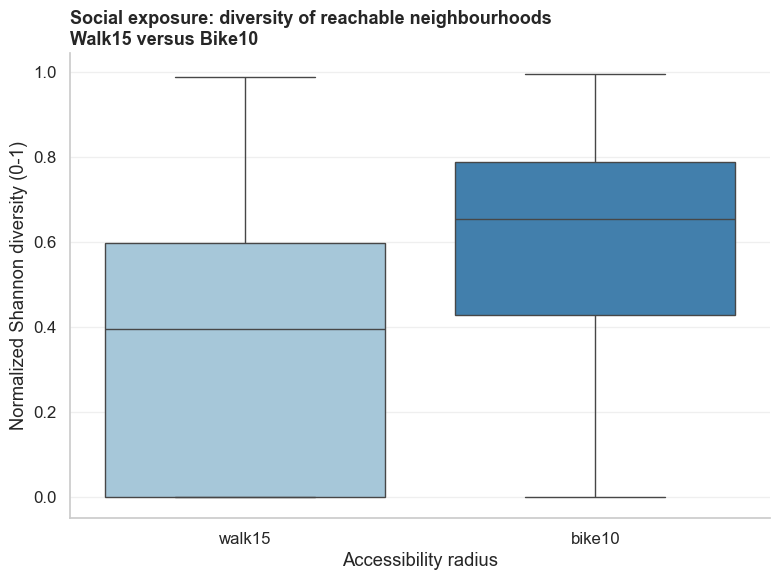

In [55]:
# Compare the diversity distribution directly between walk15 and bike10
div_long = pd.DataFrame({
    'walk15': df_social_exposure['walk15_shannon_norm'],
    'bike10': df_social_exposure['bike10_shannon_norm'],
}).melt(var_name='mode', value_name='diversity')

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=div_long, x='mode', y='diversity', hue='mode', palette=['#9ecae1', '#3182bd'], ax=ax)
if ax.legend_ is not None:
    ax.legend_.remove()
ax.set_xlabel('Accessibility radius')
ax.set_ylabel('Normalized Shannon diversity (0-1)')
ax.set_title('Social exposure: diversity of reachable neighbourhoods\nWalk15 versus Bike10', fontsize=13, fontweight='bold', loc='left')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'fig25_social_exposure_diversity_walk_vs_bike.png', dpi=150)
plt.show()


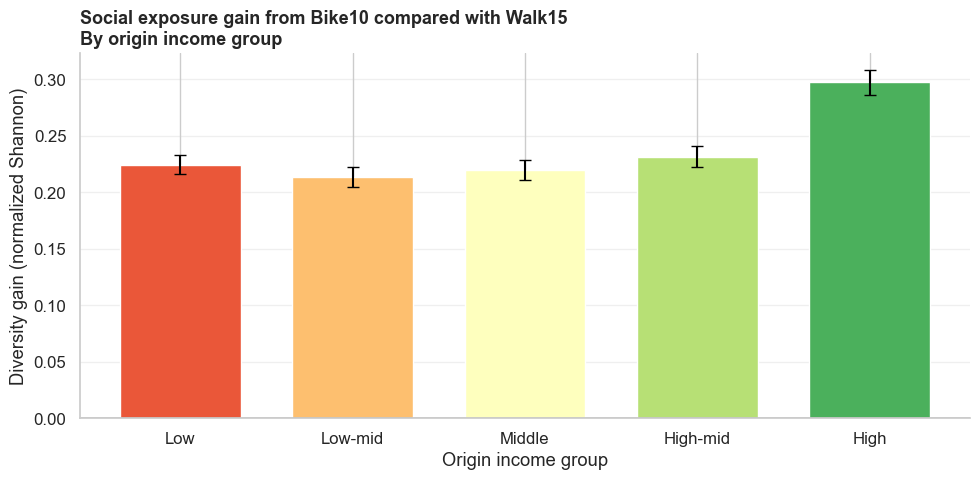

In [57]:
# Does cycling add more social exposure for some origin income groups than for others?
gain_by_income = (
    df_social_exposure.groupby('income_decile', observed=True)['diversity_gain_shannon']
    .agg(['mean', 'sem'])
    .reset_index()
)
gain_by_income['ci95'] = gain_by_income['sem'] * 1.96

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(gain_by_income['income_decile'], gain_by_income['mean'], color=sns.color_palette('RdYlGn', len(gain_by_income)), edgecolor='white', width=0.7)
ax.errorbar(gain_by_income['income_decile'], gain_by_income['mean'], yerr=gain_by_income['ci95'], fmt='none', color='black', capsize=4)
ax.axhline(0, color='black', lw=1)
ax.set_title('Social exposure gain from Bike10 compared with Walk15\nBy origin income group', fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Origin income group')
ax.set_ylabel('Diversity gain (normalized Shannon)')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'fig26_social_exposure_gain_by_origin_income.png', dpi=150)
plt.show()


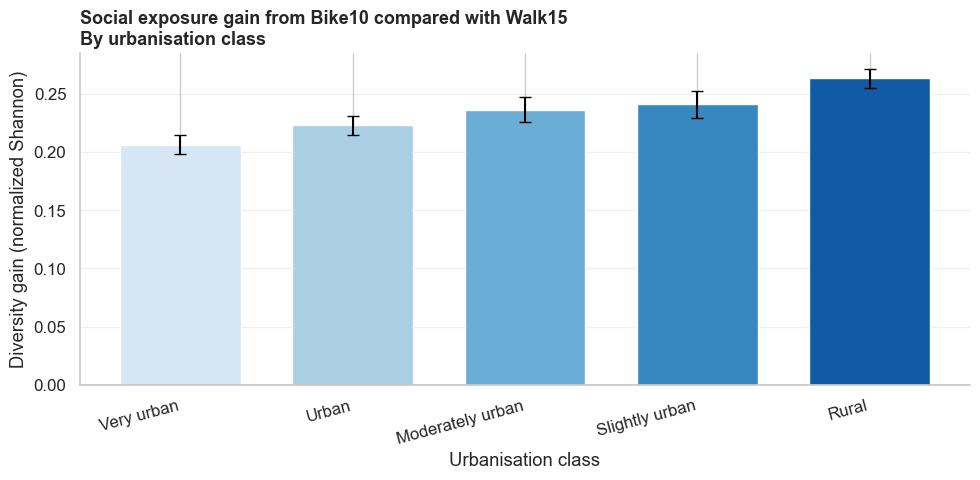

In [59]:
# Compare the diversity gain across urbanisation classes
urban_gain = (
    df_social_exposure.groupby('stedelijkheid_label', observed=True)['diversity_gain_shannon']
    .agg(['mean', 'sem'])
    .reset_index()
)
urban_order = ['Very urban', 'Urban', 'Moderately urban', 'Slightly urban', 'Rural']
urban_gain['stedelijkheid_label'] = pd.Categorical(urban_gain['stedelijkheid_label'], categories=urban_order, ordered=True)
urban_gain = urban_gain.sort_values('stedelijkheid_label')
urban_gain['ci95'] = urban_gain['sem'] * 1.96

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(urban_gain['stedelijkheid_label'], urban_gain['mean'], color=sns.color_palette('Blues', len(urban_gain)), edgecolor='white', width=0.7)
ax.errorbar(urban_gain['stedelijkheid_label'], urban_gain['mean'], yerr=urban_gain['ci95'], fmt='none', color='black', capsize=4)
ax.axhline(0, color='black', lw=1)
ax.set_title('Social exposure gain from Bike10 compared with Walk15\nBy urbanisation class', fontsize=13, fontweight='bold', loc='left')
ax.set_xlabel('Urbanisation class')
ax.set_ylabel('Diversity gain (normalized Shannon)')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'fig27_social_exposure_gain_by_urbanity.png', dpi=150)
plt.show()


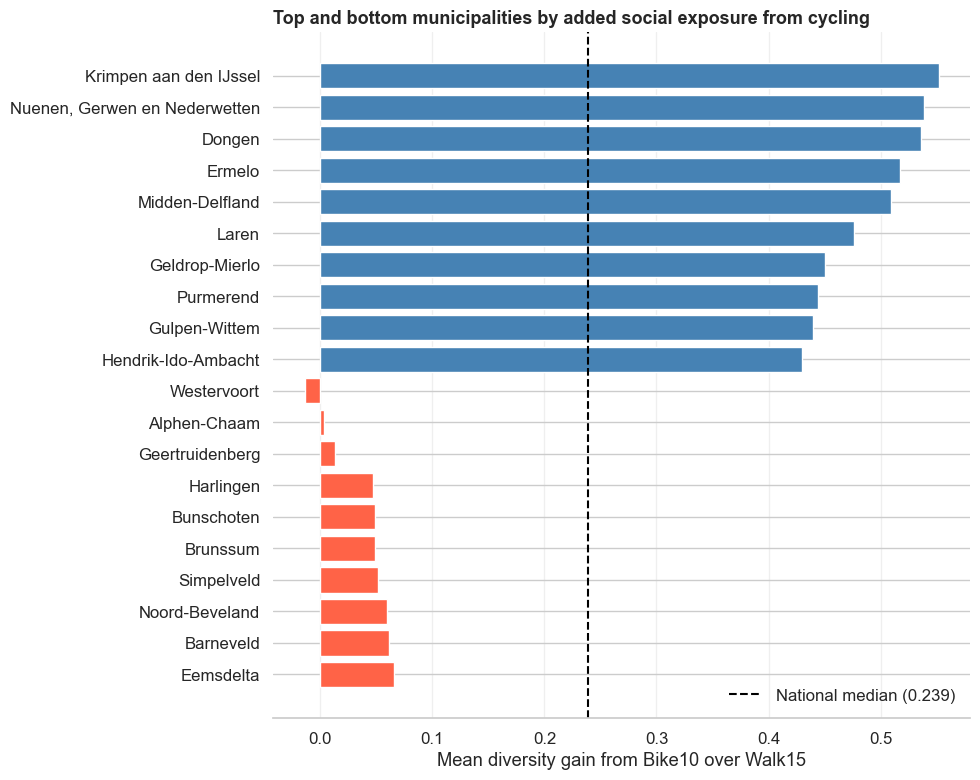

In [60]:
# Rank municipalities by how much cycling expands socioeconomic exposure beyond walking
mun_social_exposure = (
    df_social_exposure.groupby('gm_naam', observed=True)
    .agg(
        mean_walk_diversity=('walk15_shannon_norm', 'mean'),
        mean_bike_diversity=('bike10_shannon_norm', 'mean'),
        mean_diversity_gain=('diversity_gain_shannon', 'mean'),
        total_pop=('a_inw', 'sum'),
        n_buurten=('buurt_key', 'size')
    )
    .dropna()
    .query('n_buurten >= 5')
)

rank_gain = mun_social_exposure['mean_diversity_gain'].sort_values()
bottom10 = rank_gain.head(10)
top10 = rank_gain.tail(10).sort_values(ascending=False)
ranked = pd.concat([top10, bottom10])
colors = ['steelblue'] * len(top10) + ['tomato'] * len(bottom10)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(ranked.index, ranked.values, color=colors, edgecolor='white')
ax.axvline(rank_gain.median(), ls='--', color='black', lw=1.5, label=f'National median ({rank_gain.median():.3f})')
ax.set_xlabel('Mean diversity gain from Bike10 over Walk15')
ax.set_title('Top and bottom municipalities by added social exposure from cycling', fontsize=13, fontweight='bold', loc='left')
ax.legend(frameon=False)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(IMAGES_DIR / 'fig28_social_exposure_municipality_gain.png', dpi=150)
plt.show()


## 1.4 Conclusion

TODO: keep this conclusion section aligned with the final wording in the Report. The notebook structure now follows the same high-level flow as the report: Introduction, Research Questions, Methods, Results, Discussion, and Conclusion.
